# scTCR-seq Analysis | Tregs Across 6 Tissues

**Dataset:** CD4+ Tregs from bone marrow, liver, lung, skin, spleen, and thymus  
**Workflow:** Adapted from [SC Best Practices — Immune Receptor Profiling](https://www.sc-best-practices.org/air_repertoire/ir_profiling.html)  


## Imports & Configuration

In [39]:
import logging, warnings
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
from pathlib import Path

import scanpy as sc
import scanpy.external as sce
import scirpy as ir
import muon as mu

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as lines
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.pyplot import rc_context

pd.set_option('display.max_rows', 200)

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rc('font', size=12)

sc.settings.n_jobs = -1
sc.set_figure_params(dpi=80, dpi_save=300, color_map='Spectral_r', vector_friendly=True, transparent=True)
sc.settings.figdir = '../../1_outputs/0_figures'
sc.settings.verbosity = 1
sc.logging.print_header()

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [40]:
# ── Color palettes ────────────────────────────────────────────────────────────
user_defined_palette = [
    '#F6222E', '#16FF32', '#3283FE', '#FEAF16', '#BDCDFF', '#3B00FB',
    '#1CFFCE', '#C075A6', '#F8A19F', '#B5EFB5', '#FBE426', '#C4451C',
    '#2ED9FF', '#c1c119', '#8b0000', '#FE00FA', '#1CBE4F', '#1C8356',
    '#0e452b', '#AA0DFE', '#B5EFB5', '#325A9B', '#90AD1C'
]

user_defined_cmap_markers = LinearSegmentedColormap.from_list(
    'mycmap', ["#E6E6FF", "#CCCCFF", "#B2B2FF", "#9999FF", "#6666FF", "#3333FF", "#0000FF"]
)
user_defined_cmap_degs = LinearSegmentedColormap.from_list(
    'mycmap', [
        "#0000FF", "#3333FF", "#6666FF", "#9999FF", "#B2B2FF", "#CCCCFF",
        "#E6E6FF", "#E6FFE6", "#CCFFCC", "#B2FFB2", "#99FF99", "#66FF66",
        "#33FF33", "#00FF00"
    ]
)

# Tissue-specific palette (6 tissues)
tissue_palette = {
    'bm':     '#3283FE',
    'liver':  '#FEAF16',
    'lung':   '#1CFFCE',
    'skin':   '#F6222E',
    'spleen': '#AA0DFE',
    'thymus': '#16FF32',
}

# Treg status palette
treg_palette = {
    '0:Regenerative': '#3283FE',
    '1:Quiescent':    '#F6222E',
}

## Data Loading

In [41]:
# ── Output and data paths ─────────────────────────────────────────────────────
file_outputs = '1_outputs/'
h5ad = '../0_scRNA/1_outputs/1_h5ad/'

h5_path  = '/coh_labs/mvandenbrink/users/jonpierce/tff1/scRNA/h5Files/h5adFiles/'
tcr_path = '/coh_labs/mvandenbrink/users/jonpierce/tff1/scRNA/vdjFiles/'

In [42]:
# ── Load pre-processed GEX AnnData ───────────────────────────────────────────
adata = sc.read_h5ad(h5ad + '11_adata_final.h5ad')

# Backup and clean barcodes (strip trailing -<digit> added by AnnData.concatenate)
adata.obs["barcode_preclean"] = adata.obs_names.copy()
adata.obs_names = [re.sub(r"-\d+$", "", bc) for bc in adata.obs_names]

print(f"GEX: {adata.n_obs:,} cells \u00d7 {adata.n_vars:,} genes")
adata.obs.head(2)

GEX: 30,553 cells × 20,682 genes


,tissue,hash_id,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,leiden_0.9,leiden_1.0,keep_cell,tissue_labeled,spectra50,treg_regen,treg_supress,treg_naive,treg_status,barcode_preclean
thymus_GGCTTCCTCACGACAC,thymus,C0303,3559,8.177516,11589,9.357898,32.228838,37.949780,45.310208,58.236259,...,3,6,0.yes,0:Thymus,-0.046394,-0.056213,0.603170,-0.144485,0:Regenerative,thymus_GGCTTCCTCACGACAC-1
thymus_AGTAAGCAGCAAACTT,thymus,C0301,1816,7.504942,3499,8.160518,24.178337,30.523007,40.097171,59.016862,...,0,0,0.yes,0:Thymus,0.087199,-0.091307,0.296141,-0.100388,0:Regenerative,thymus_AGTAAGCAGCAAACTT-1


In [43]:
# ── Load 10x VDJ files (one per tissue) ──────────────────────────────────────
tcr_files = {
    "bm":     tcr_path + "bm_filtered_contig_annotations.csv",
    "liver":  tcr_path + "liver_filtered_contig_annotations.csv",
    "lung":   tcr_path + "lung_filtered_contig_annotations.csv",
    "skin":   tcr_path + "skin_filtered_contig_annotations.csv",
    "spleen": tcr_path + "spleen_filtered_contig_annotations.csv",
    "thymus": tcr_path + "thymus_filtered_contig_annotations.csv",
}

vdj_objects = {}
for tissue, path in tcr_files.items():
    vdj = ir.io.read_10x_vdj(path)
    vdj.obs_names = f"{tissue}_" + vdj.obs_names
    vdj.obs["tissue"] = tissue
    vdj_objects[tissue] = vdj
    print(f"  {tissue}: {vdj.n_obs:,} cells")

  bm: 4,012 cells
  liver: 2,840 cells
  lung: 697 cells
  skin: 651 cells
  spleen: 10,363 cells
  thymus: 9,518 cells


In [44]:
# ── Concatenate all VDJ objects ───────────────────────────────────────────────
vdj_all = vdj_objects["bm"].concatenate(
    *[v for k, v in vdj_objects.items() if k != "bm"],
    batch_key="tissue"
)

# Backup and clean barcodes
# Strips both the AnnData concat suffix AND the 10x gem-well suffix (e.g. -1-5 -> "")
vdj_all.obs["barcode_preclean"] = vdj_all.obs_names.copy()
vdj_all.obs_names = [re.sub(r"(-\d+)+$", "", bc) for bc in vdj_all.obs_names]

print(f"AIRR total: {vdj_all.n_obs:,} cells")
vdj_all.obs_names[:5]

AIRR total: 28,081 cells


Index(['bm_AAACCAAAGGGGTGTA', 'bm_AAACCAGCAAAGCGTA', 'bm_AAACCAGCACAGTAAG',
       'bm_AAACCAGCAGCAACGG', 'bm_AAACCCCAGACGAAGT'],
      dtype='object')

In [45]:
# ── Create multimodal MuData object ──────────────────────────────────────────
mdata = mu.MuData({"gex": adata, "airr": vdj_all})

# Remove cells with no tissue assignment (unmatched GEX/AIRR barcodes)
n_before = mdata.n_obs
mu.pp.filter_obs(mdata, "gex:tissue", lambda x: x.notna())
n_after = mdata.n_obs
print(f"Removed {n_before - n_after:,} NaN-tissue cells ({n_before:,} \u2192 {n_after:,})")

mdata

Removed 3,434 NaN-tissue cells (33,987 → 30,553)


MuData object with n_obs × n_vars = 30553 × 20682
  2 modalities
    gex:	30553 x 20682
      obs:	'tissue', 'hash_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'ribo_frac', 'hb_frac', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'n_counts', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'keep_cell', 'tissue_labeled', 'spectra50', 'treg_regen', 'treg_supress', 'treg_naive', 'treg_status', 'barcode_preclean'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg', 'neighbors', 'pca', 'tissue_labeled_colors', 'treg_status_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'raw_data'
      obsp:	'connectivities', 'distances'
    airr:	24647 x 0
      obs:	'tissue', 'barcode_preclean'
      obsm:	'airr'

## TCR Quality Control

Assess chain pairing quality per tissue. Expected benchmarks (SC Best Practices):
- >60% single AIRs (paired α+β)
- 10–20% orphan chains (acceptable)
- Multichain cells flagged as likely doublets

**Chain pairing categories:**
| Category | Meaning |
|----------|---------|
| `single pair` | Complete paired TCR (α+β) ✓ |
| `orphan VJ` | Only α-chain detected |
| `orphan VDJ` | Only β-chain detected |
| `extra VJ` / `extra VDJ` | Paired + extra chain |
| `two full chains` | Two complete pairs |
| `multichain` | >2 chains (likely doublet) ✗ |

In [46]:
# ── Assign chain indices and compute chain QC ─────────────────────────────────
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

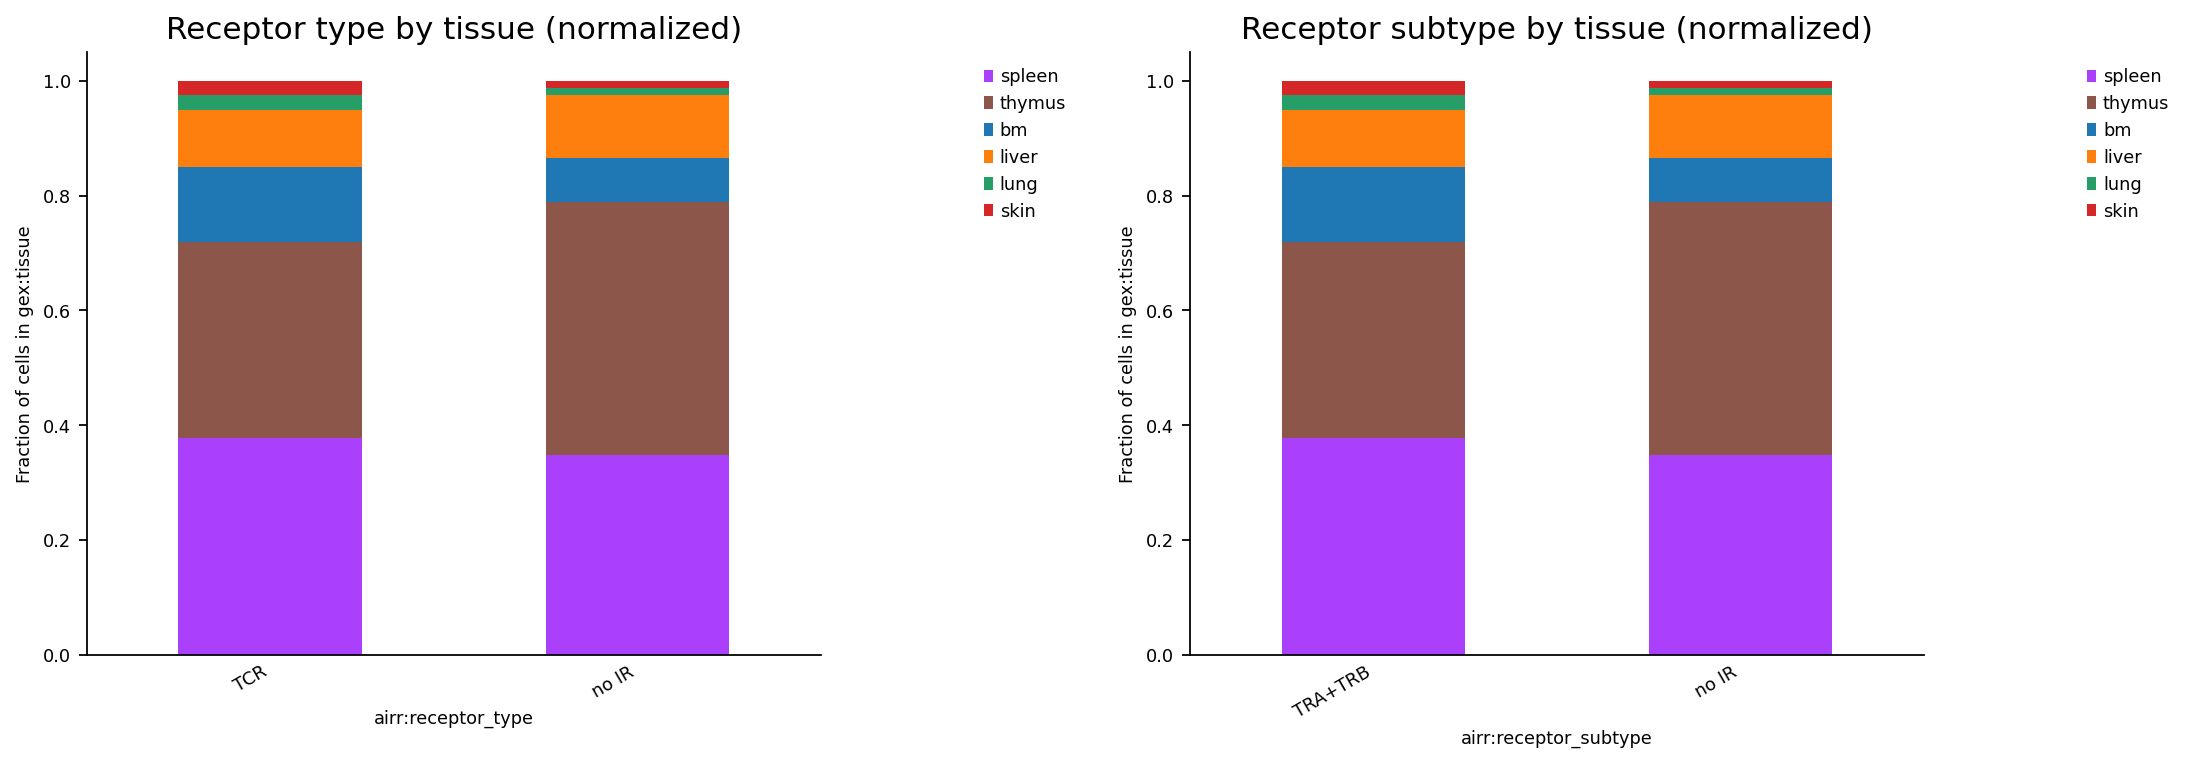

In [47]:
# ── Receptor type and subtype by tissue (normalized) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ir.pl.group_abundance(
    mdata, groupby="airr:receptor_type", target_col="gex:tissue",
    normalize=True, ax=axes[0]
)
axes[0].set_title("Receptor type by tissue (normalized)")

ir.pl.group_abundance(
    mdata, groupby="airr:receptor_subtype", target_col="gex:tissue",
    normalize=True, ax=axes[1]
)
axes[1].set_title("Receptor subtype by tissue (normalized)")

plt.tight_layout()
plt.show()

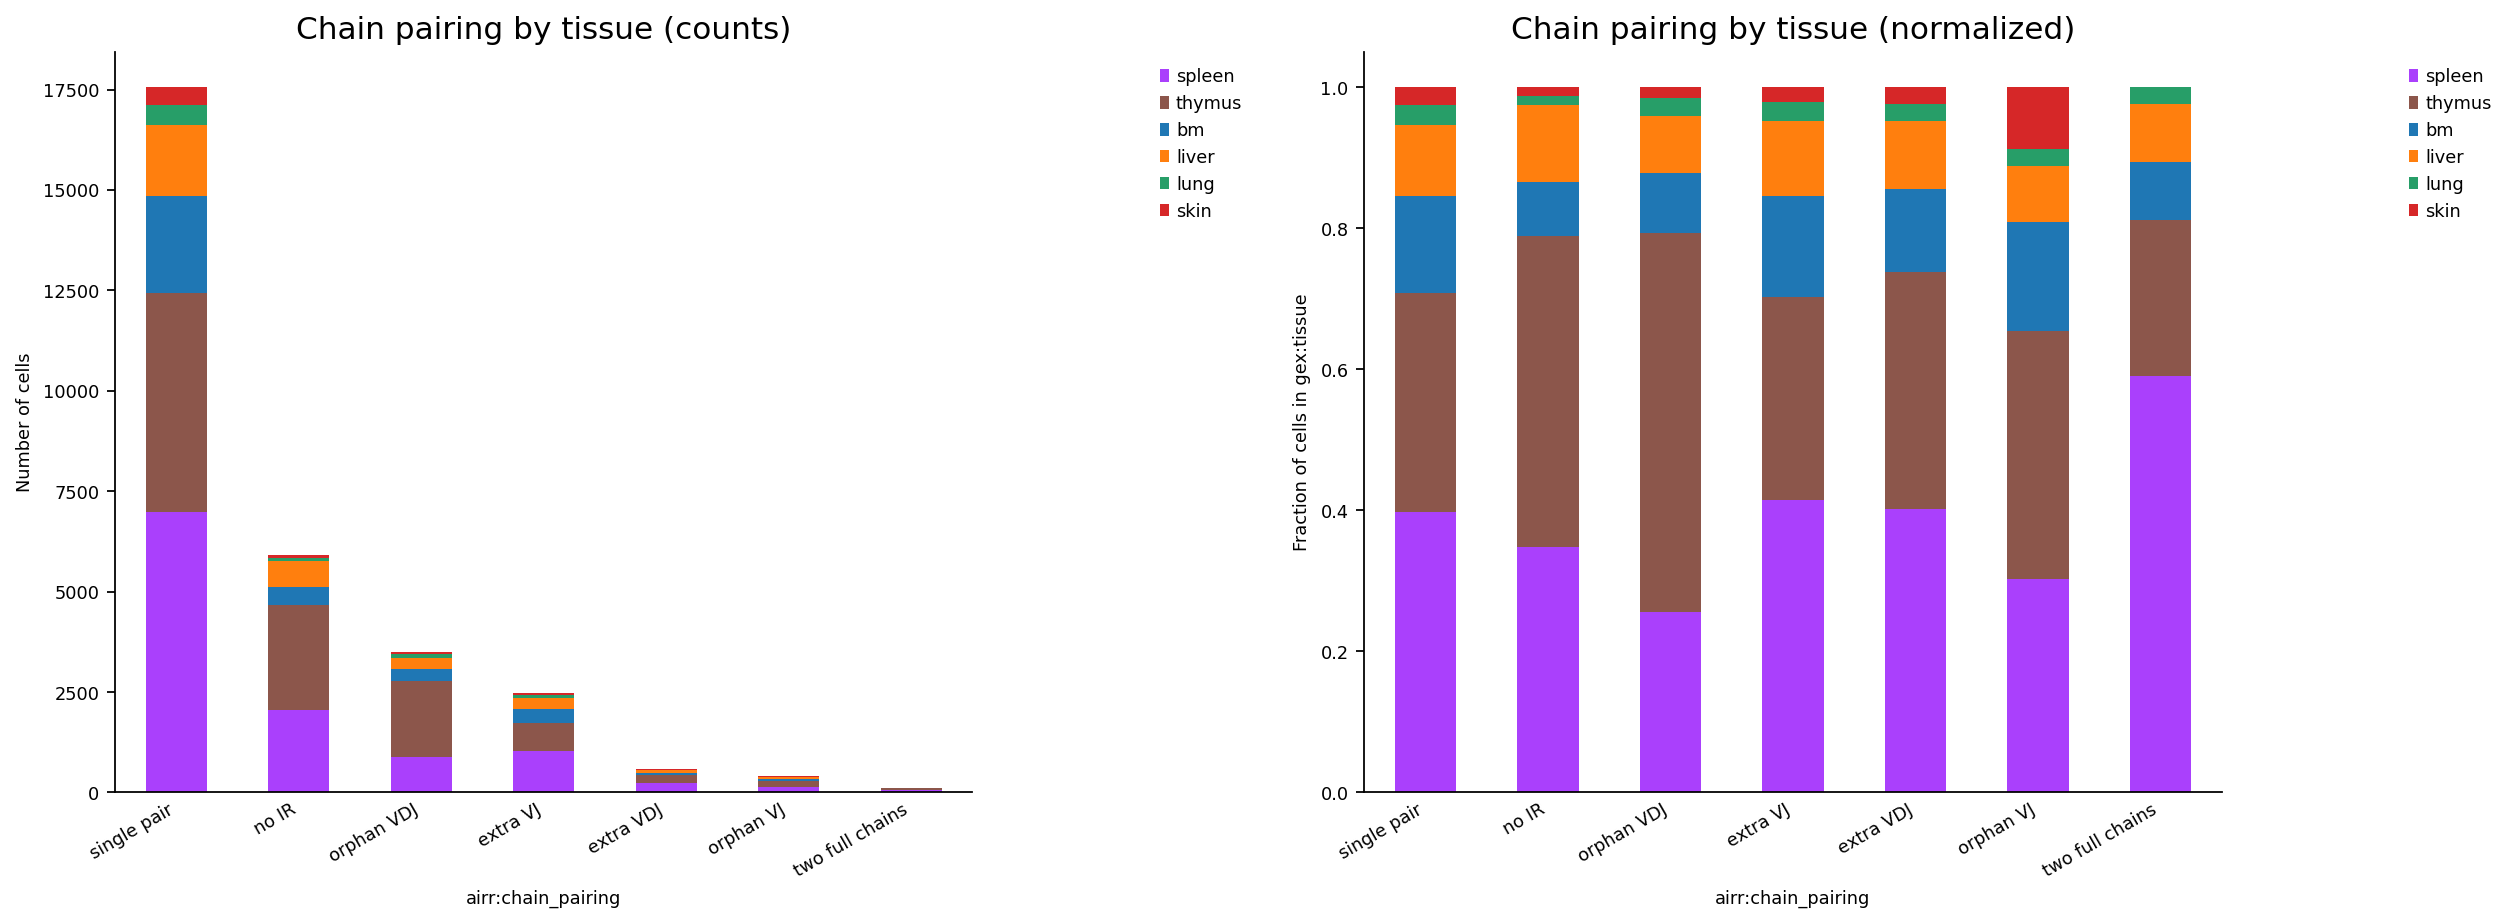

In [48]:
# ── Chain pairing by tissue (absolute and normalized) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ir.pl.group_abundance(
    mdata, groupby="airr:chain_pairing", target_col="gex:tissue",
    normalize=False, ax=axes[0]
)
axes[0].set_title("Chain pairing by tissue (counts)")

ir.pl.group_abundance(
    mdata, groupby="airr:chain_pairing", target_col="gex:tissue",
    normalize=True, ax=axes[1]
)
axes[1].set_title("Chain pairing by tissue (normalized)")

plt.tight_layout()
plt.show()

In [49]:
# ── Summary: chain pairing categories ────────────────────────────────────────
multi_mask = mdata.obs["airr:chain_pairing"].isin(
    ["extra VJ", "extra VDJ", "two full chains", "multichain"]
)
print(
    f"Fraction with >1 TCR pair: {multi_mask.sum() / mdata['airr'].n_obs:.2%}  "
    f"({multi_mask.sum():,} / {mdata['airr'].n_obs:,} AIRR cells)"
)
print()
print(mdata.obs["airr:chain_pairing"].value_counts().to_string())

Fraction with >1 TCR pair: 12.87%  (3,173 / 24,647 AIRR cells)

airr:chain_pairing
single pair        17562
no IR               5906
orphan VDJ          3493
extra VJ            2472
extra VDJ            579
orphan VJ            419
two full chains      122


In [50]:
# ── Progressive filtering with cell counts at each step ──────────────────────
n_total = mdata.n_obs
n_no_ir = (mdata.obs["airr:chain_pairing"] == "no IR").sum()
n_multichain = (mdata.obs["airr:chain_pairing"] == "multichain").sum()
n_single = (mdata.obs["airr:chain_pairing"] == "single pair").sum()

print(f"All cells:                {n_total:>7,}")
print(f"  - no IR:                {n_no_ir:>7,}")
print(f"  - multichain (doublets):{n_multichain:>7,}")
print(f"  = single pair retained: {n_single:>7,}")

# Apply filter: keep single pair only
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: x == "single pair")
print(f"\nMuData after filtering: {mdata.n_obs:,} cells")

All cells:                 30,553
  - no IR:                  5,906
  - multichain (doublets):      0
  = single pair retained:  17,562

MuData after filtering: 17,562 cells


In [51]:
# ── Verify: tissue breakdown after filtering ──────────────────────────────────
print("Cells per tissue after filtering:")
print(mdata.obs.groupby("gex:tissue", dropna=False).size().to_string())

Cells per tissue after filtering:
gex:tissue
bm        2415
liver     1772
lung       478
skin       458
spleen    6975
thymus    5464


## Clonotype Definition

Two levels of clonotype grouping:
- **3a. Nucleotide (exact match):** identical CDR3 nt sequences on both chains → `clonotype_id`
- **3b. Amino acid (cluster-based):** similar CDR3 aa sequences → `cc_aa_identity`

> **Parameter note:** `min_cells=5` used for network layouts (vs. default 50) because some tissues have only ~450–480 single-pair cells (lung, skin).

### Nucleotide-level clonotypes (exact match)

In [52]:
# ── Compute nucleotide sequence distances (default) ───────────────────────────
ir.pp.ir_dist(mdata)  # sequence='nt' by default

# Define clonotypes: require identical CDR3 on both chains, use primary IR only
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")

In [53]:
# ── Generate clonotype network layout (nucleotide) ────────────────────────────
# min_cells=5: show clonotypes with >=5 cells (reduced from default 50 for small tissues)
ir.tl.clonotype_network(mdata, min_cells=5)

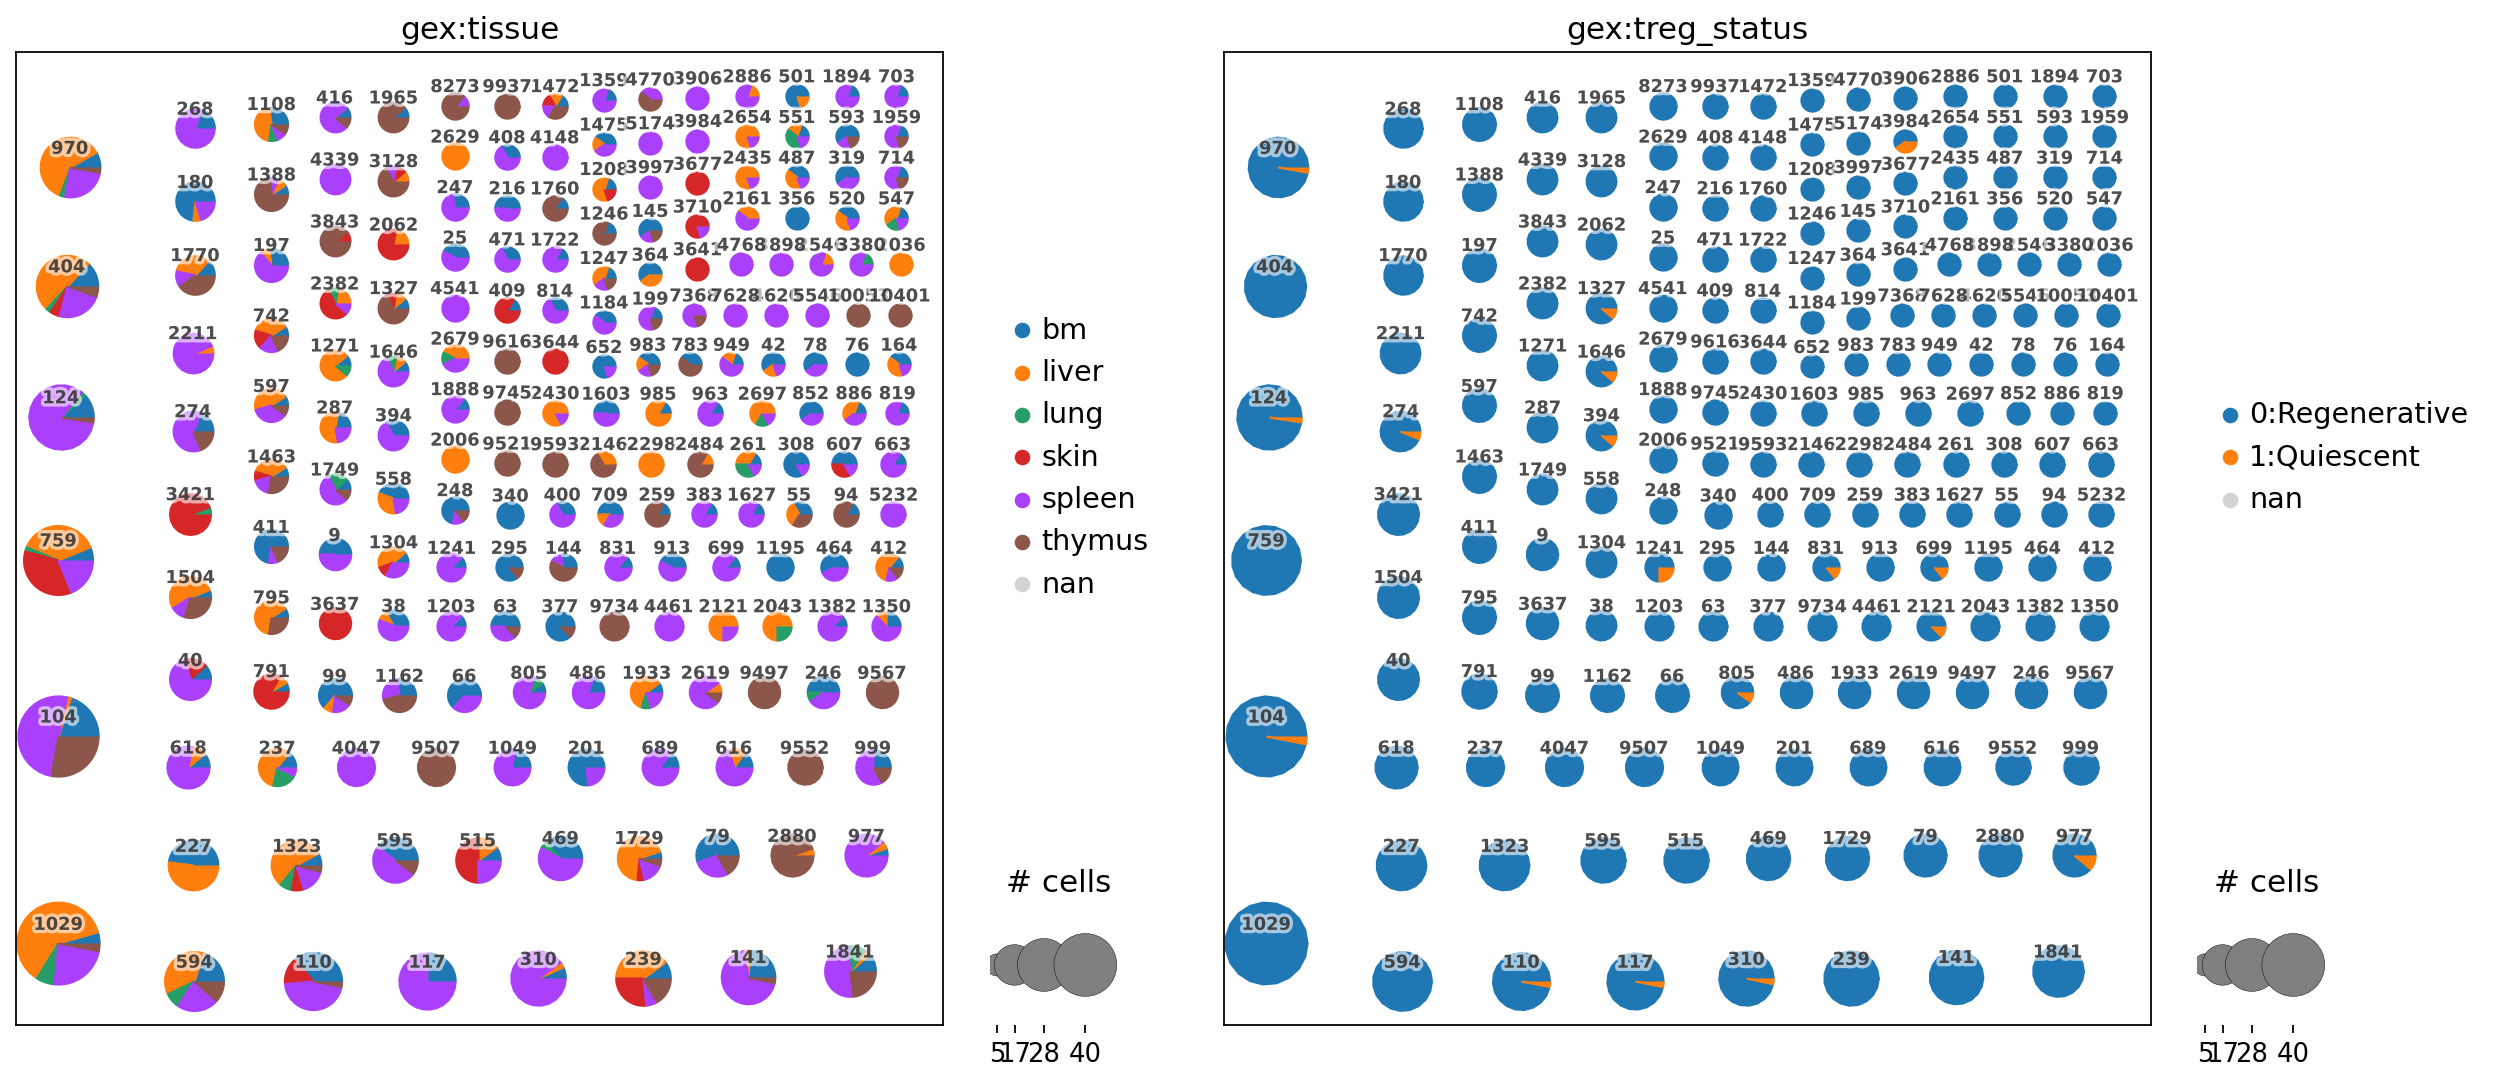

In [54]:
# ── Clonotype network (nt): colored by tissue and by Treg status ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ir.pl.clonotype_network(
    mdata, color="gex:tissue", base_size=20, label_fontsize=8,
    panel_size=(7, 7), ax=axes[0]
)

ir.pl.clonotype_network(
    mdata, color="gex:treg_status", base_size=20, label_fontsize=8,
    panel_size=(7, 7), ax=axes[1]
)

plt.tight_layout()
plt.show()

### Amino acid-level clonotype clusters

In [55]:
# ── Compute amino acid sequence distances ─────────────────────────────────────
ir.pp.ir_dist(mdata, sequence="aa")

# Define clonotype clusters: aa similarity, both arms, accept any dual IR configuration
ir.tl.define_clonotype_clusters(
    mdata, sequence="aa", receptor_arms="all", dual_ir="any"
)

# Convert cluster ID to string for downstream plotting compatibility
mdata.obs["airr:cc_aa_identity"] = mdata.obs["airr:cc_aa_identity"].astype("str")

In [56]:
# ── Generate clonotype network layout (amino acid) ────────────────────────────
ir.tl.clonotype_network(mdata, min_cells=5, sequence="aa")

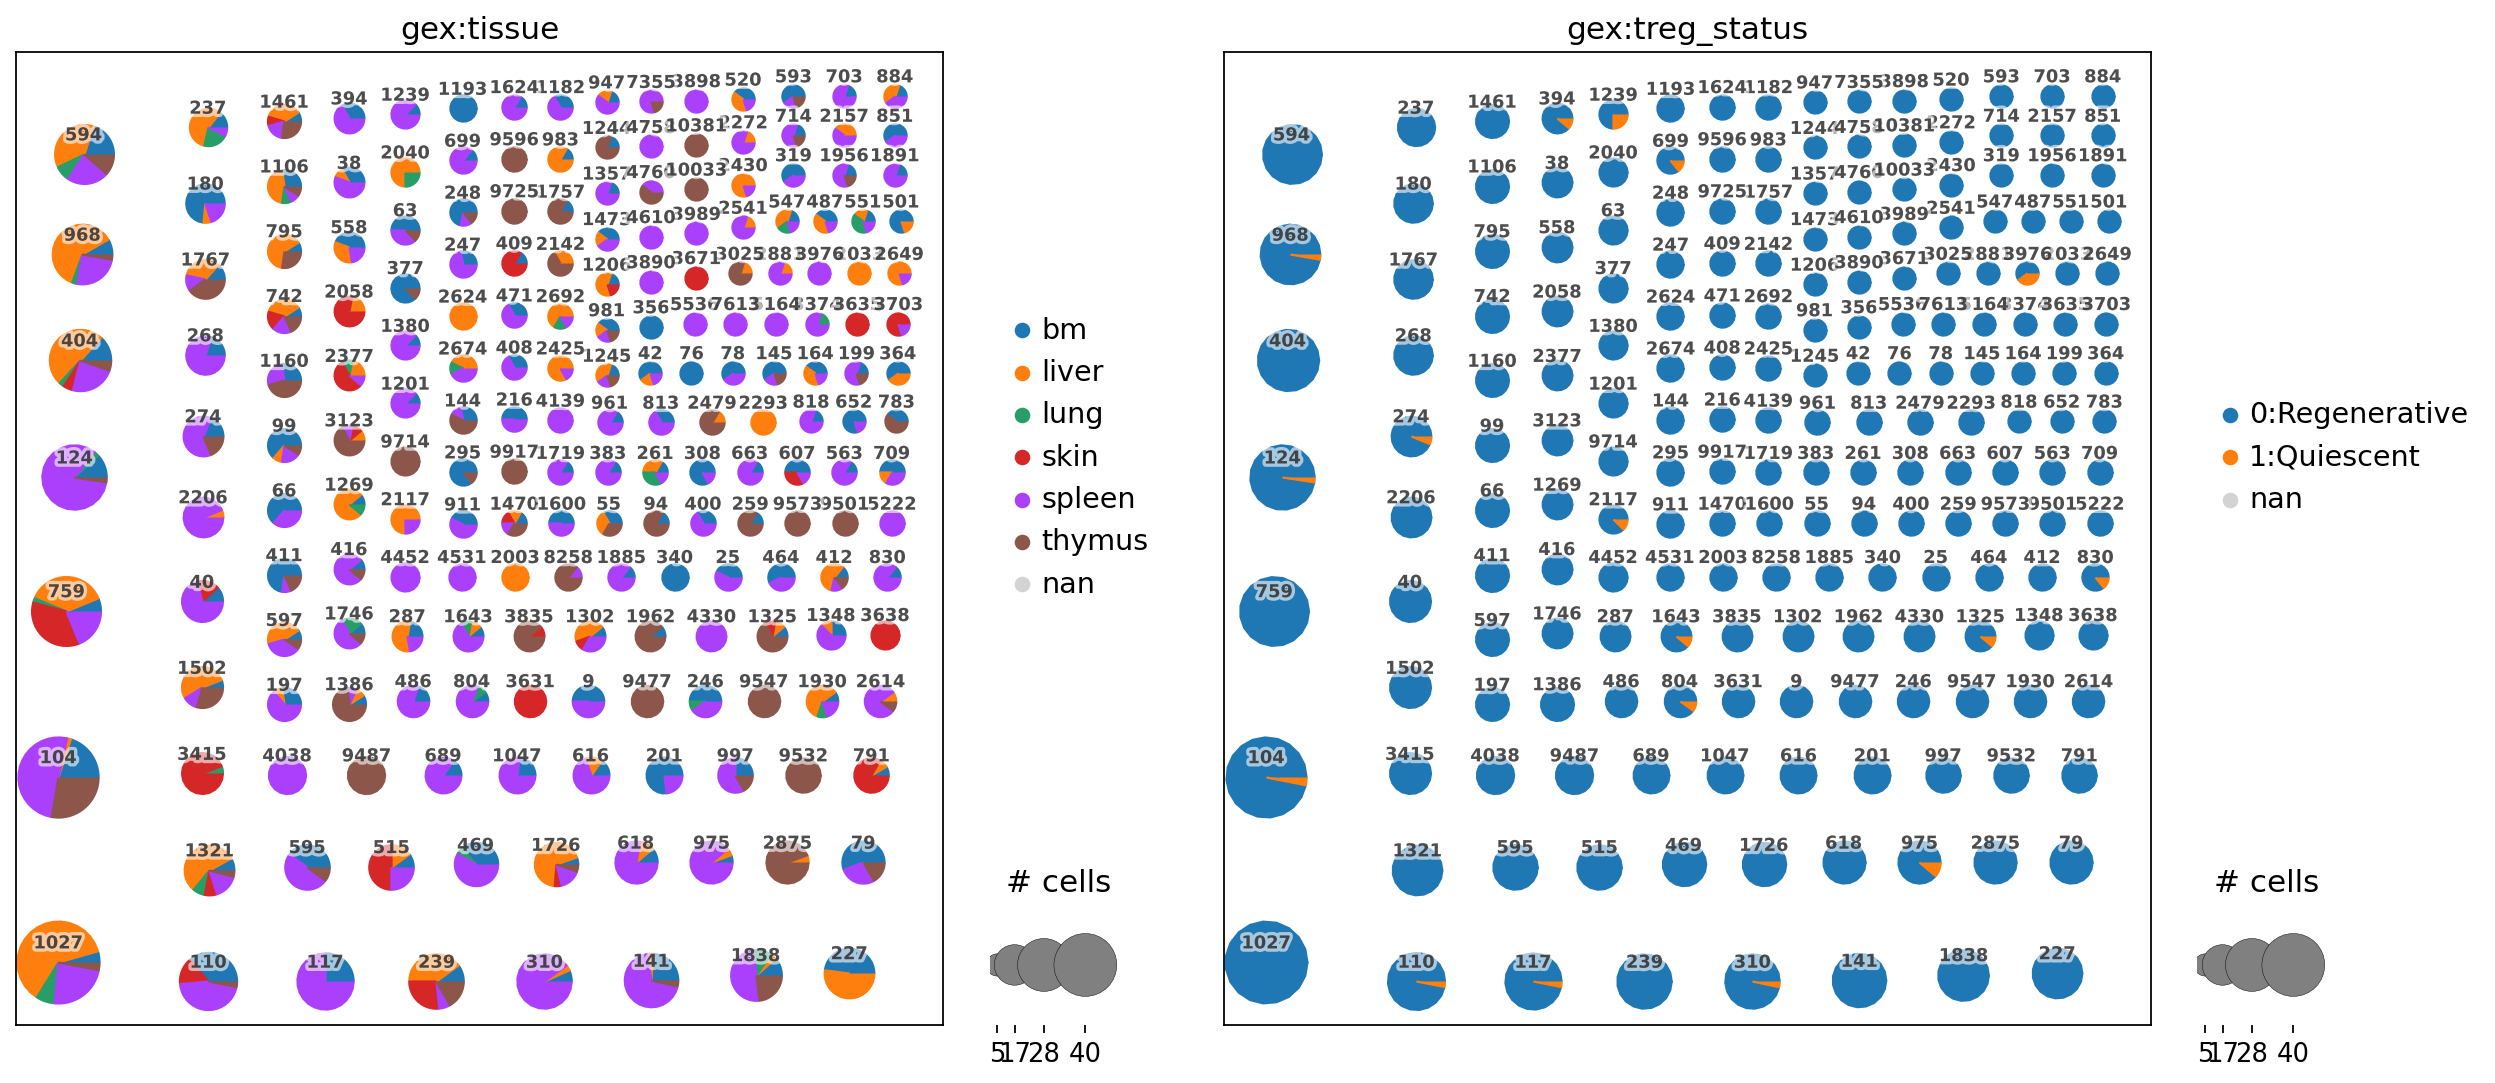

In [57]:
# ── Clonotype network (aa): colored by tissue and by Treg status ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ir.pl.clonotype_network(
    mdata, color="gex:tissue", base_size=20, label_fontsize=8,
    panel_size=(7, 7), ax=axes[0]
)

ir.pl.clonotype_network(
    mdata, color="gex:treg_status", base_size=20, label_fontsize=8,
    panel_size=(7, 7), ax=axes[1]
)

plt.tight_layout()
plt.show()

## Clonal Expansion

Quantify the proportion of expanded vs. singleton clonotypes per tissue and Treg status.  
`clip_at=4`: cells in clonotypes with ≥4 members are grouped into the top bin.

In [58]:
# ── Compute clonal expansion ──────────────────────────────────────────────────
ir.tl.clonal_expansion(mdata, target_col="airr:cc_aa_identity")

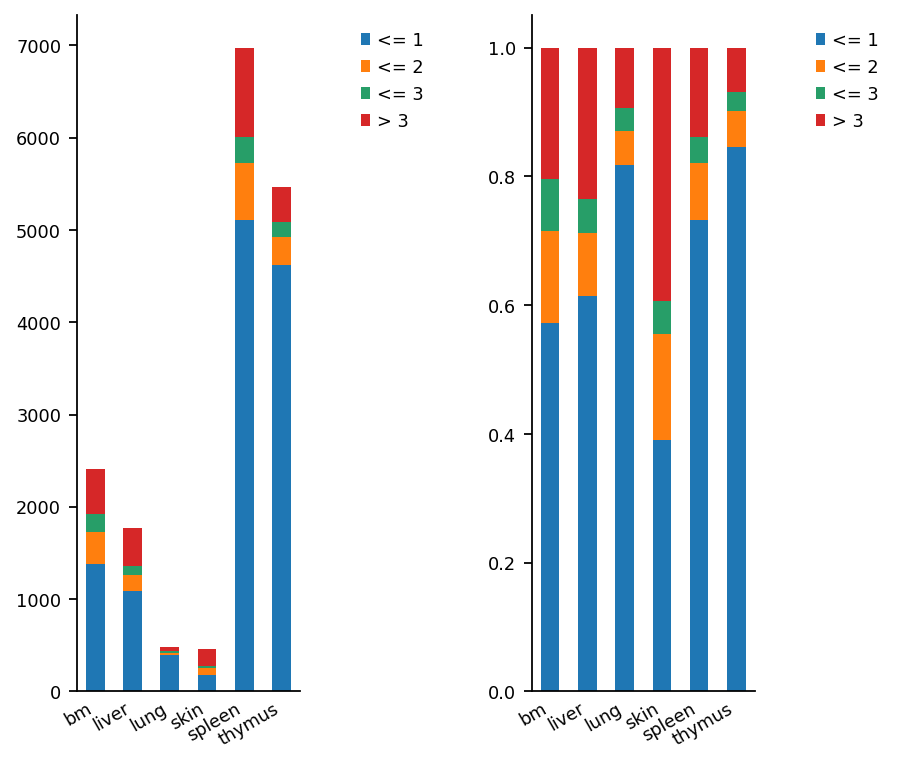

In [59]:
# ── Clonal expansion by tissue (absolute and normalized) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ir.pl.clonal_expansion(
    mdata, groupby="gex:tissue", target_col="cc_aa_identity",
    clip_at=4, normalize=False, figsize=[6, 5], ax=axes[0]
)

ir.pl.clonal_expansion(
    mdata, groupby="gex:tissue", target_col="cc_aa_identity",
    clip_at=4, normalize=True, figsize=[6, 5], ax=axes[1]
)

plt.tight_layout()
plt.show()

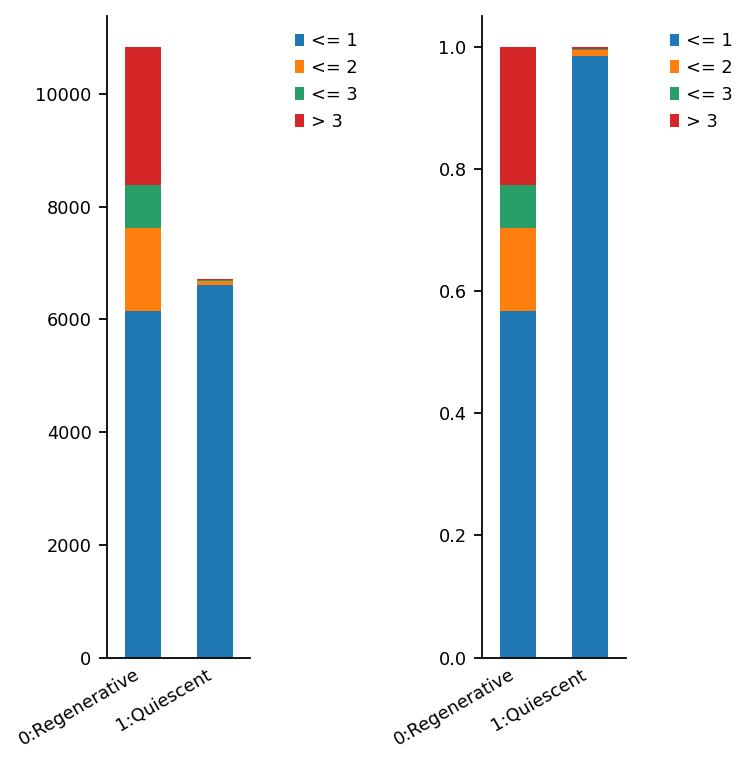

In [60]:
# ── Clonal expansion by Treg status (absolute and normalized) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ir.pl.clonal_expansion(
    mdata, groupby="gex:treg_status", target_col="cc_aa_identity",
    clip_at=4, normalize=False, figsize=[5, 5], ax=axes[0]
)

ir.pl.clonal_expansion(
    mdata, groupby="gex:treg_status", target_col="cc_aa_identity",
    clip_at=4, normalize=True, figsize=[5, 5], ax=axes[1]
)

plt.tight_layout()
plt.show()

## Diversity Analysis

- **Alpha diversity:** within-sample clonotype richness per tissue and Treg status
- **Repertoire overlap (beta diversity):** pairwise clonotype sharing across the 6 tissues (Jaccard index)

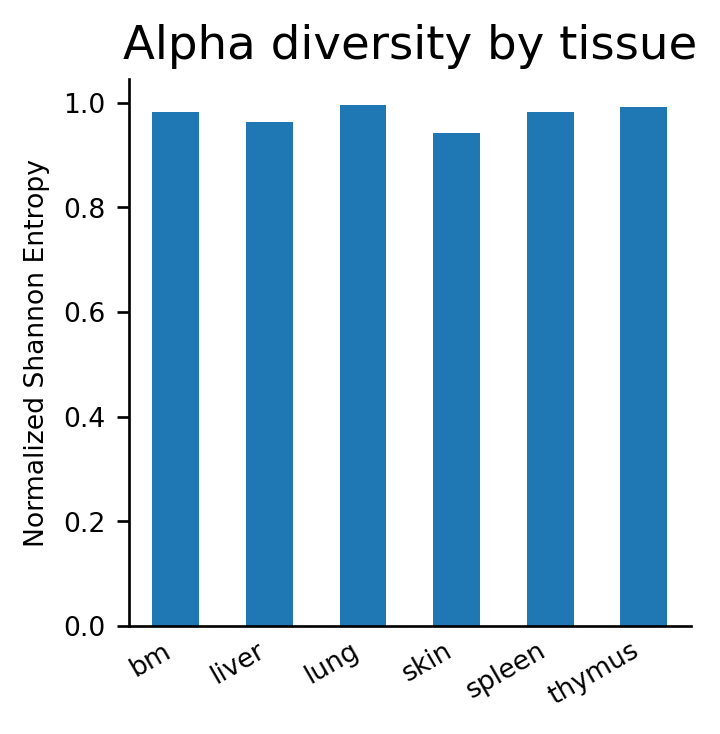

In [61]:
# ── Alpha diversity by tissue ─────────────────────────────────────────────────
_ = ir.pl.alpha_diversity(
    mdata,
    groupby="gex:tissue",
    target_col="airr:cc_aa_identity",
    figsize=[3, 3]
)
plt.title("Alpha diversity by tissue")
plt.show()

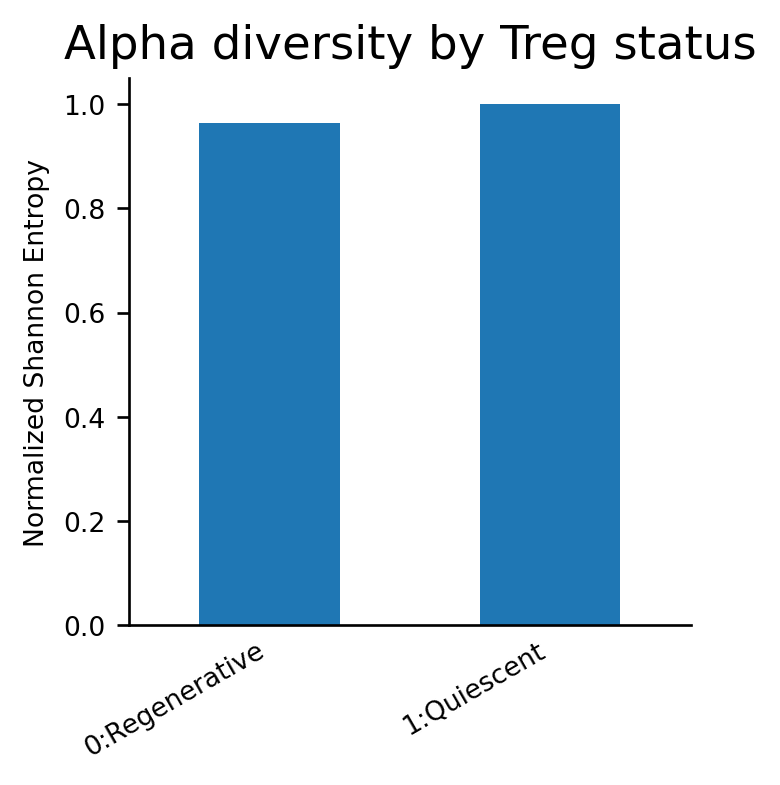

In [62]:
# ── Alpha diversity by Treg status ────────────────────────────────────────────
_ = ir.pl.alpha_diversity(
    mdata,
    groupby="gex:treg_status",
    target_col="airr:cc_aa_identity",
    figsize=[3, 3]
)
plt.title("Alpha diversity by Treg status")
plt.show()

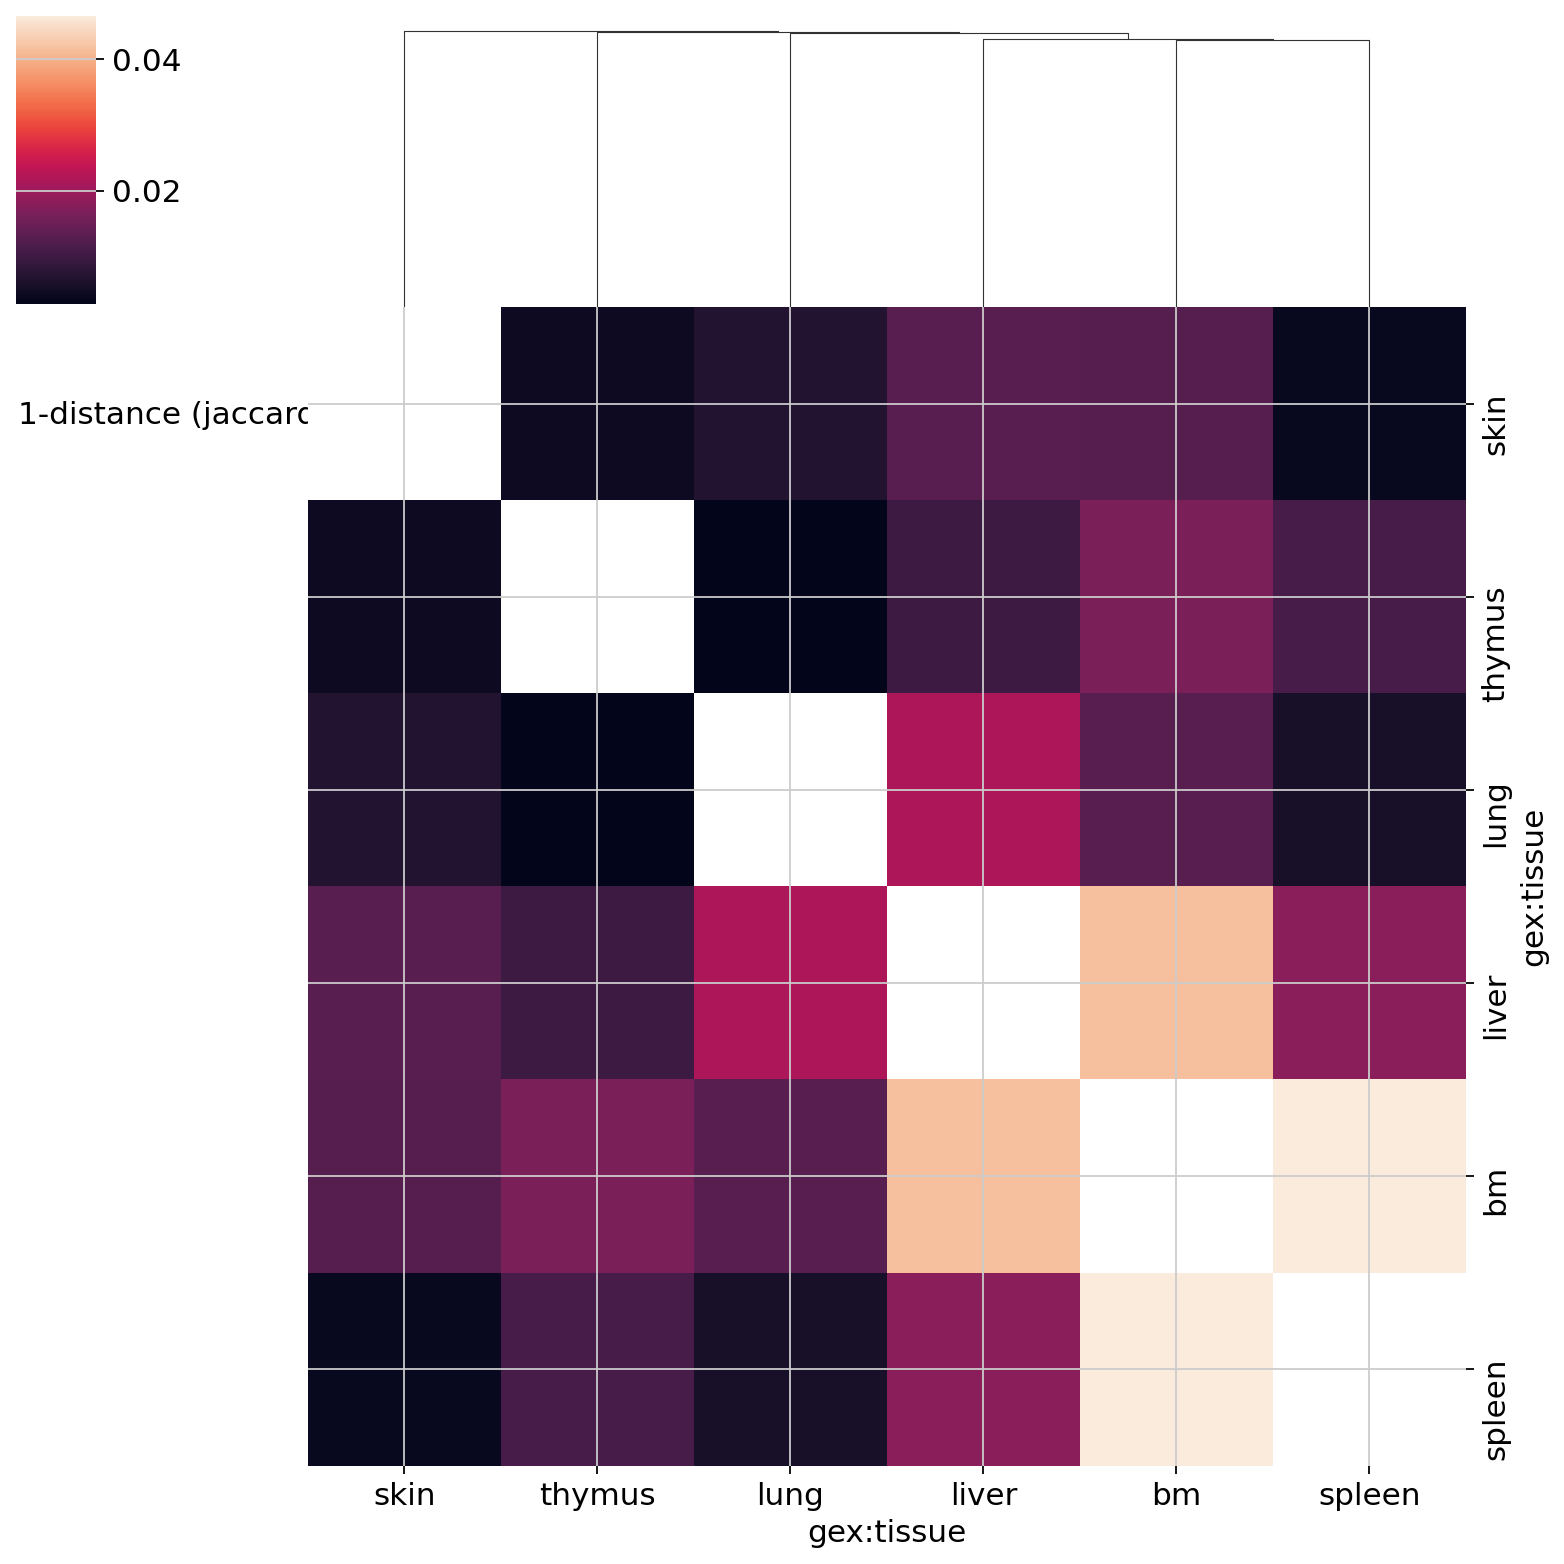

In [63]:
# ── Repertoire overlap across 6 tissues (beta diversity heatmap) ──────────────
# Computes pairwise Jaccard overlap of clonotype clusters between tissues
df_overlap, dst, lk = ir.tl.repertoire_overlap(
    mdata,
    "gex:tissue",
    target_col="airr:cc_aa_identity",
    inplace=False
)

_ = ir.pl.repertoire_overlap(
    mdata,
    "gex:tissue",
    target_col="airr:cc_aa_identity"
)

## V(D)J Gene Usage

V gene usage in TCR α and β chains, stratified by tissue and Treg status.

| Column | Chain | Gene segment |
|--------|-------|--------------|
| `airr:IR_VJ_1_v_call` | α-chain (VJ) | TRAV |
| `airr:IR_VDJ_1_v_call` | β-chain (VDJ) | TRBV |

All plots normalized to enable cross-tissue and cross-status comparisons.

In [64]:
mdata

MuData object with n_obs × n_vars = 17562 × 20682
  2 modalities
    gex:	17562 x 20682
      obs:	'tissue', 'hash_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'ribo_frac', 'hb_frac', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'n_counts', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'keep_cell', 'tissue_labeled', 'spectra50', 'treg_regen', 'treg_supress', 'treg_naive', 'treg_status', 'barcode_preclean'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg', 'neighbors', 'pca', 'tissue_labeled_colors', 'treg_status_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'raw_data'
      obsp:	'connectivities', 'distances'
    airr:	17562 x 0
      obs:	'tissue', 'barcode_preclean', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_identity', 'cc_aa_identity_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id', 'clonotype_network', 'ir_dist_aa_identity', 'cc_aa_identity', 'repertoire_overlap'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'

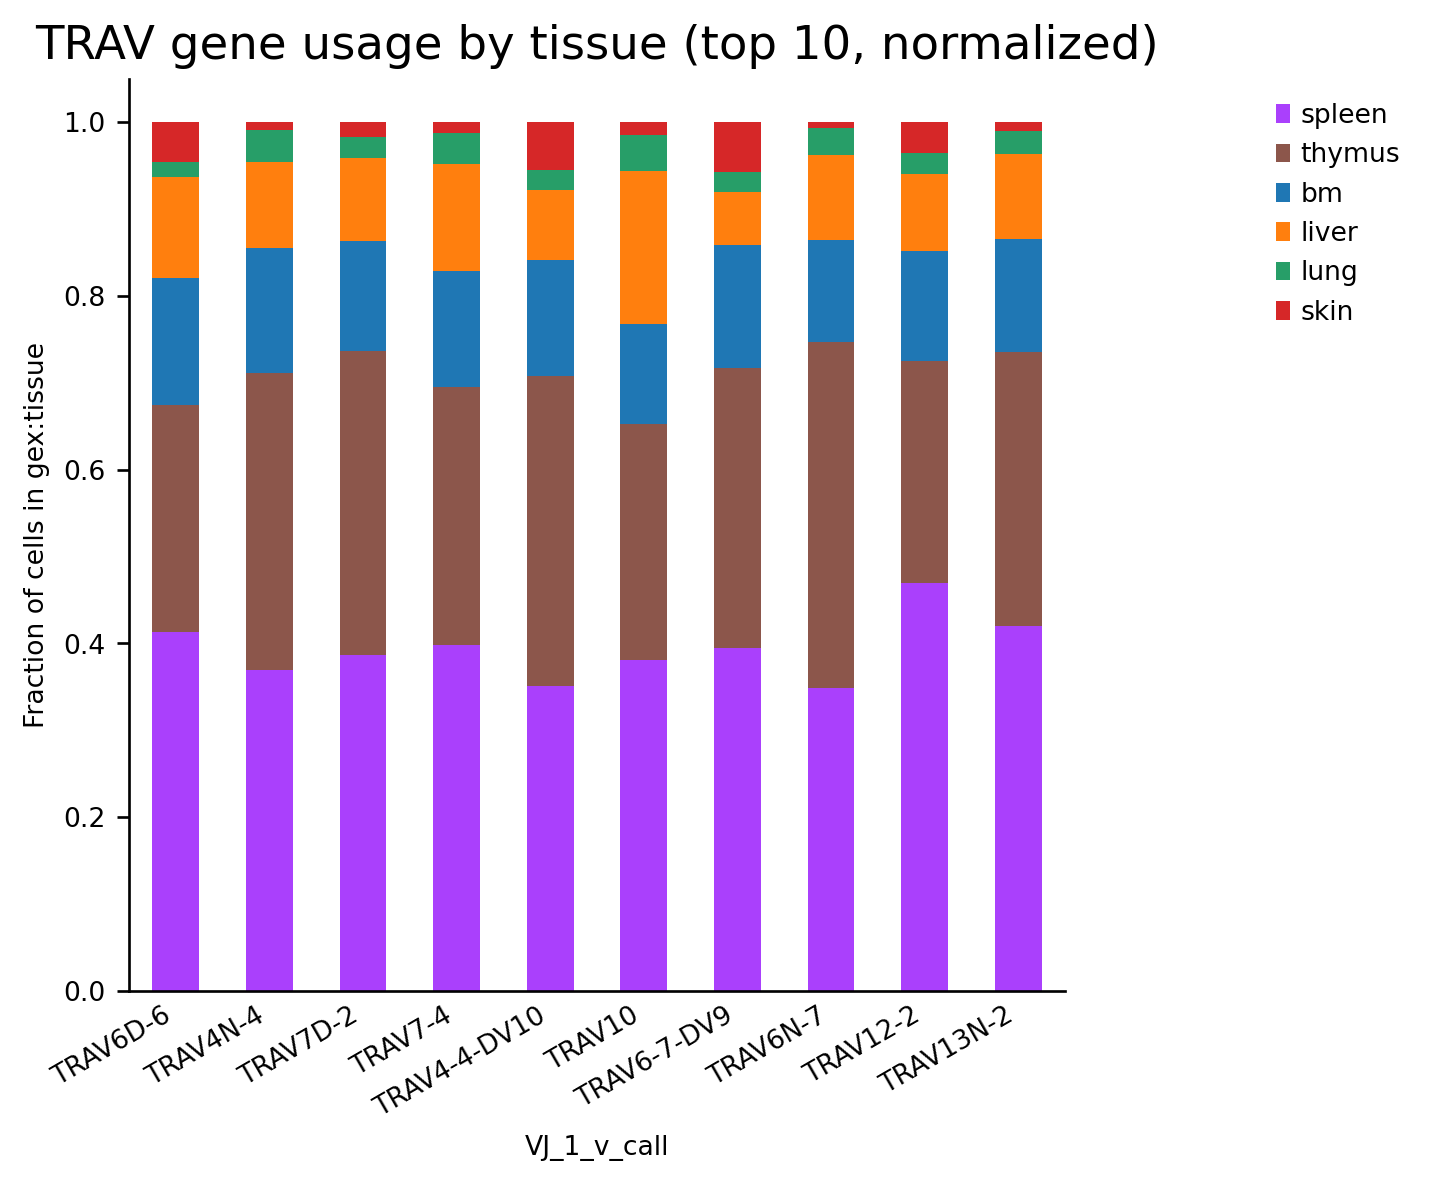

In [65]:
# ── TRAV (α-chain) usage by tissue ────────────────────────────────────────────
with ir.get.airr_context(mdata, "v_call"):
    _ = ir.pl.group_abundance(
        mdata,
        groupby="VJ_1_v_call",
        target_col="gex:tissue",
        normalize=True,
        max_cols=10,
        figsize=[5, 5]
    )
plt.title("TRAV gene usage by tissue (top 10, normalized)")
plt.show()

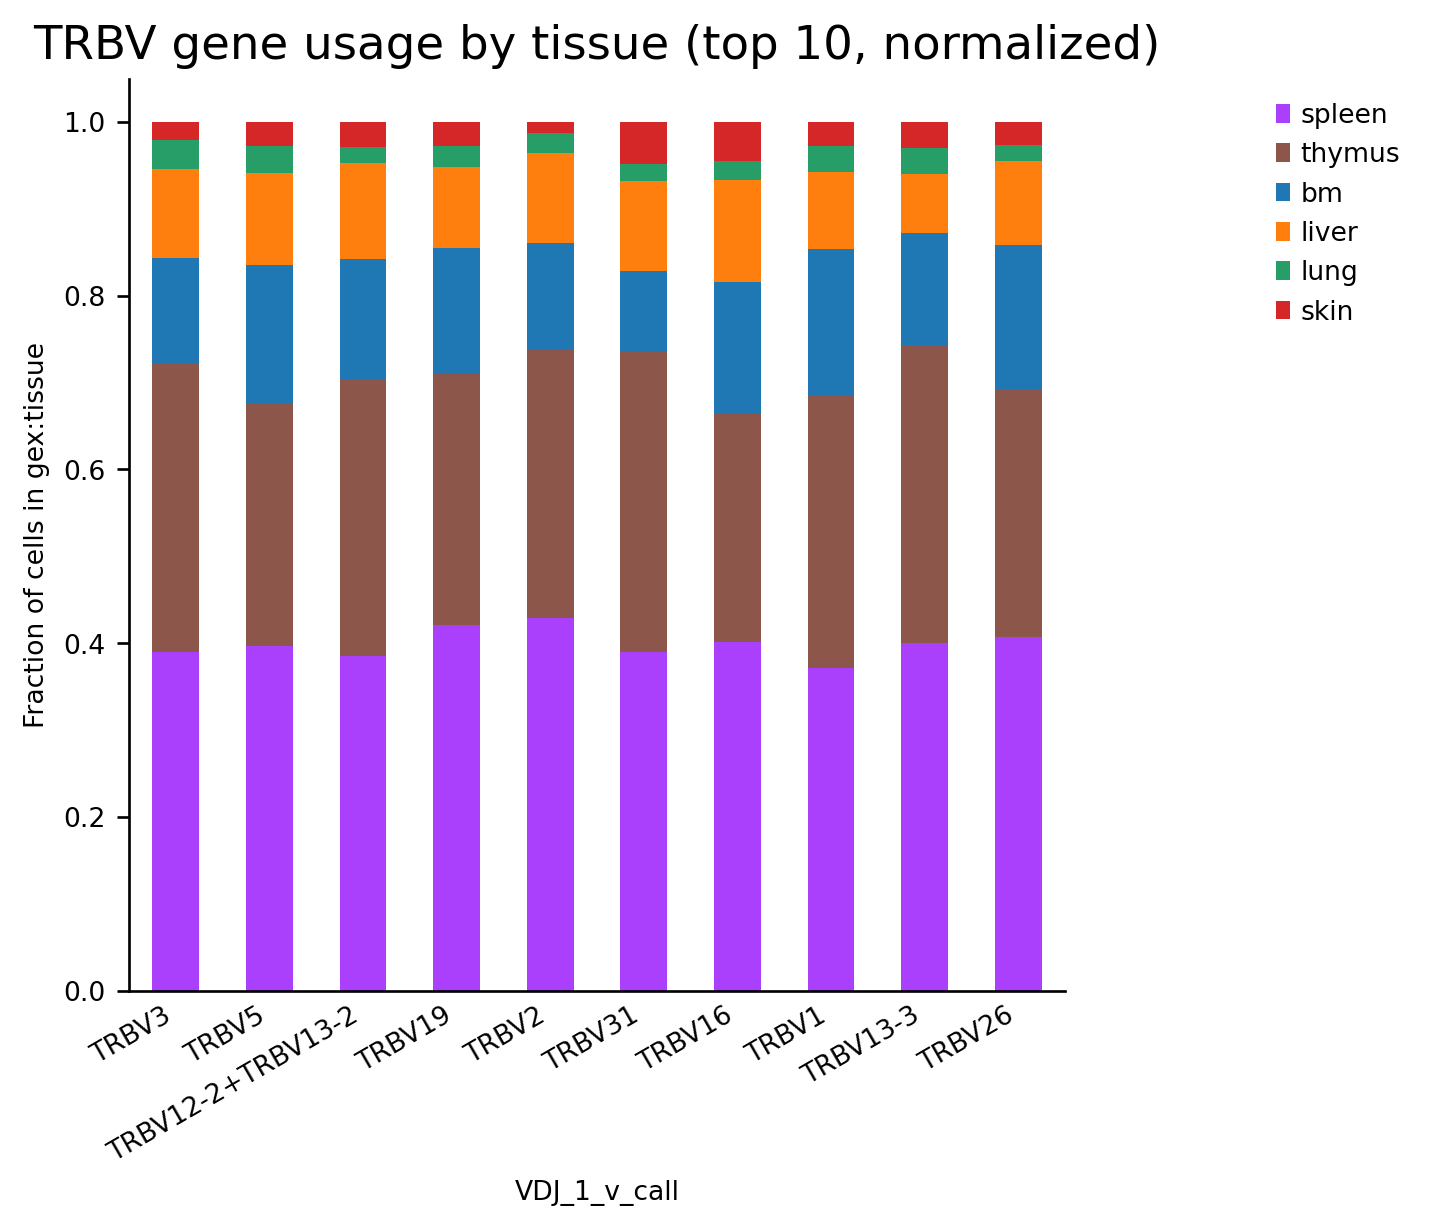

In [66]:
# ── TRBV (β-chain) usage by tissue ────────────────────────────────────────────
with ir.get.airr_context(mdata, "v_call"):
    _ = ir.pl.group_abundance(
        mdata,
        groupby="VDJ_1_v_call",
        target_col="gex:tissue",
        normalize=True,
        max_cols=10,
        figsize=[5, 5]
    )
    plt.title("TRBV gene usage by tissue (top 10, normalized)")
    plt.show()

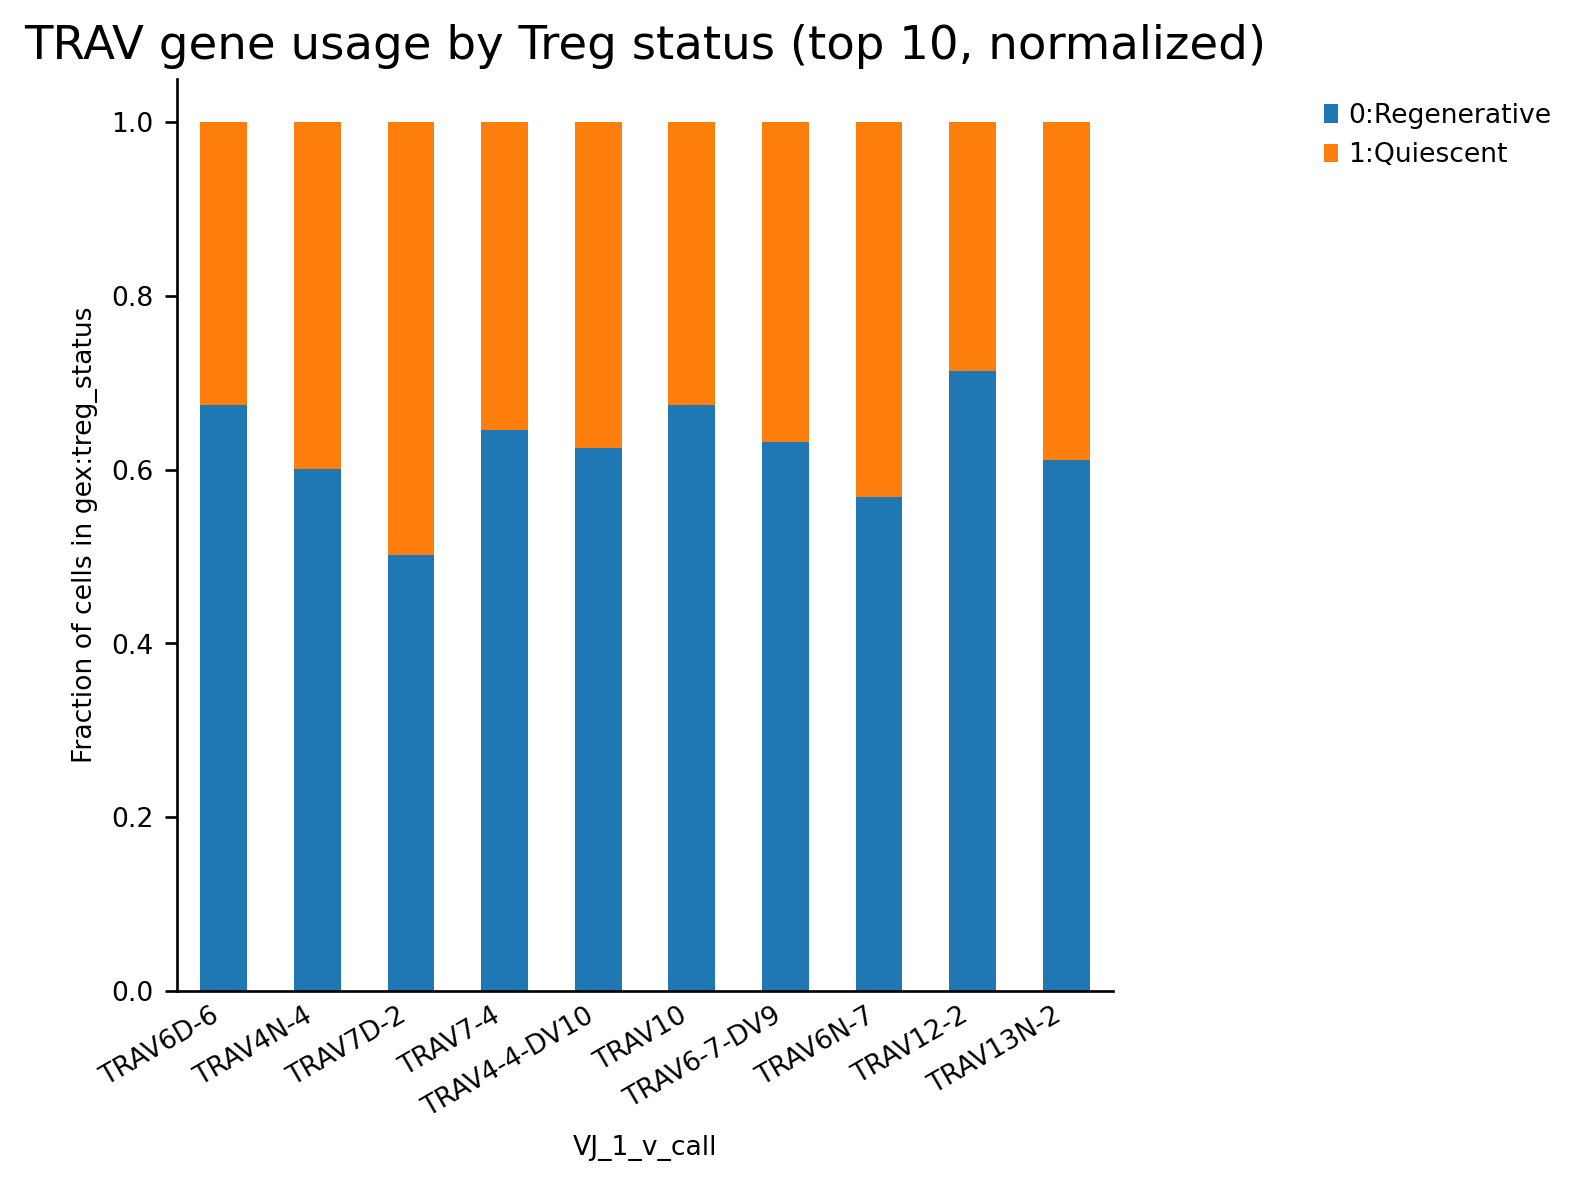

In [67]:
# ── TRAV (α-chain) usage by Treg status ──────────────────────────────────────
with ir.get.airr_context(mdata, "v_call"):
    _ = ir.pl.group_abundance(
        mdata,
        groupby="VJ_1_v_call",
        target_col="gex:treg_status",
        normalize=True,
        max_cols=10,
        figsize=[5, 5]
    )
plt.title("TRAV gene usage by Treg status (top 10, normalized)")
plt.show()

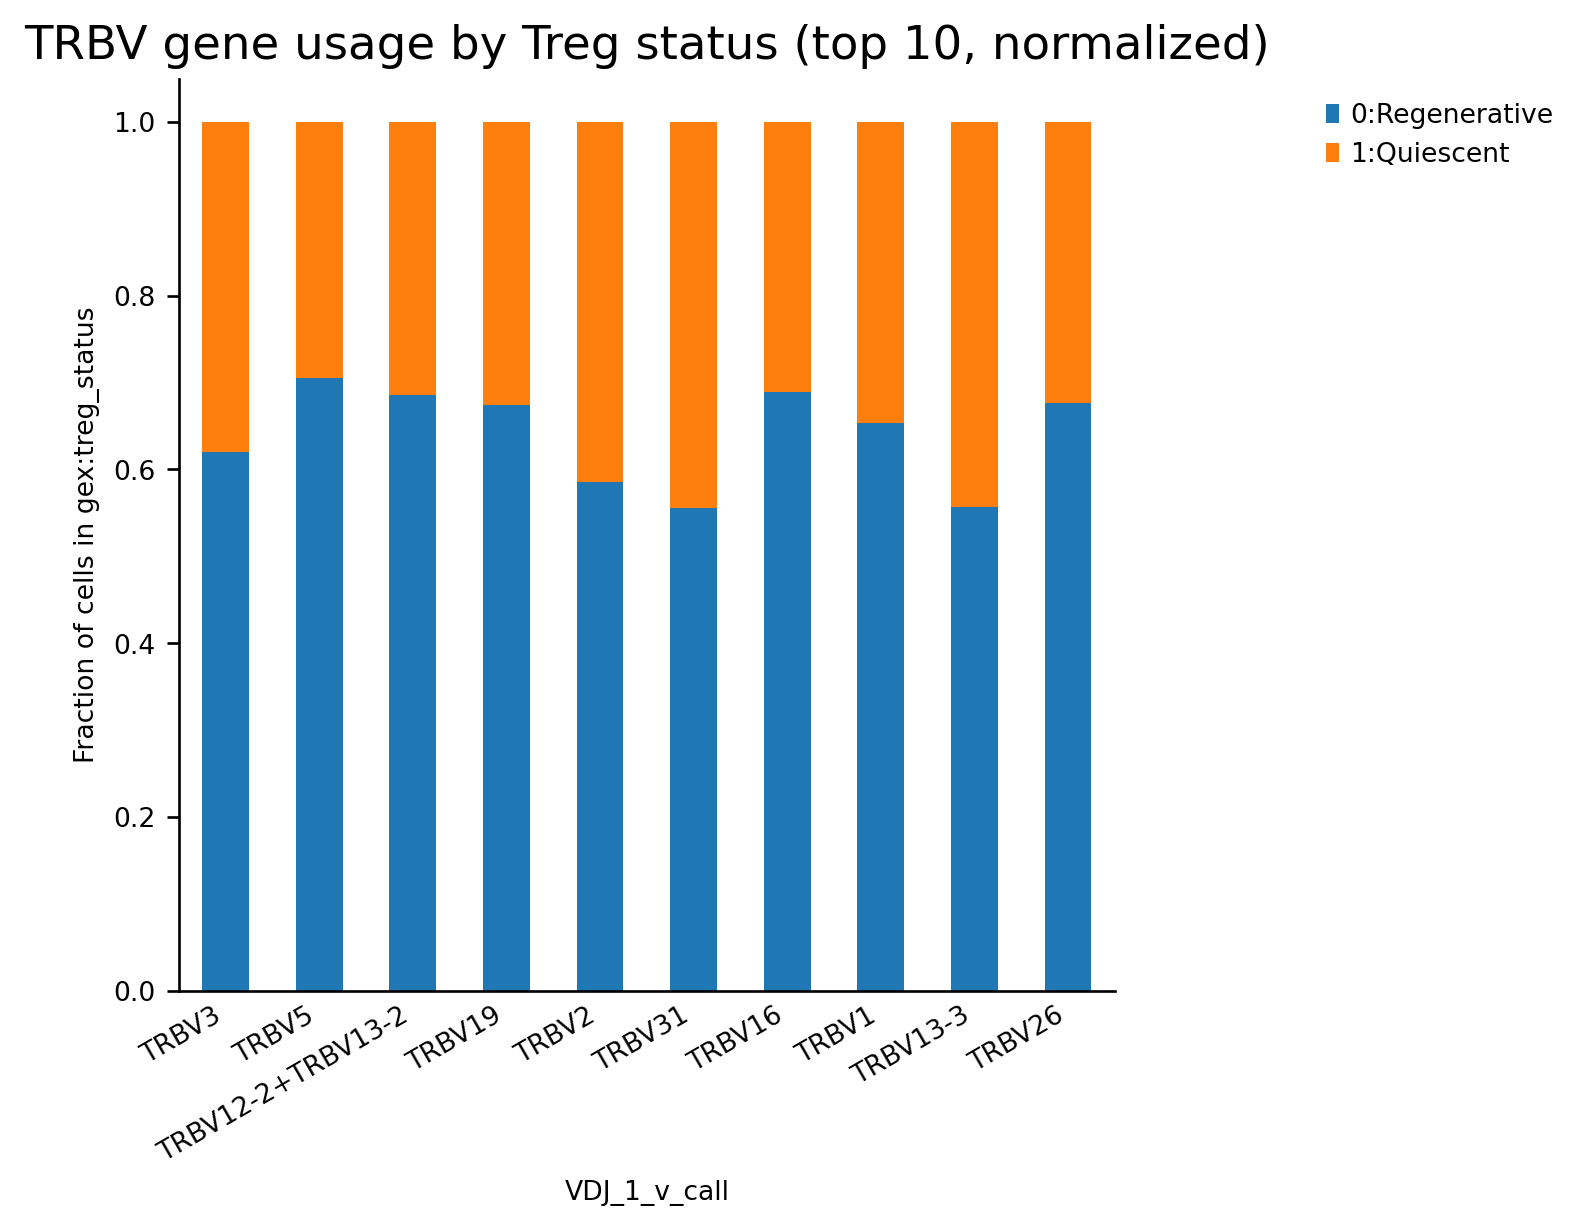

In [68]:
# ── TRBV (β-chain) usage by Treg status ──────────────────────────────────────
with ir.get.airr_context(mdata, "v_call"):
    _ = ir.pl.group_abundance(
        mdata,
        groupby="VDJ_1_v_call",
        target_col="gex:treg_status",
        normalize=True,
        max_cols=10,
        figsize=[5, 5]
    )
plt.title("TRBV gene usage by Treg status (top 10, normalized)")
plt.show()

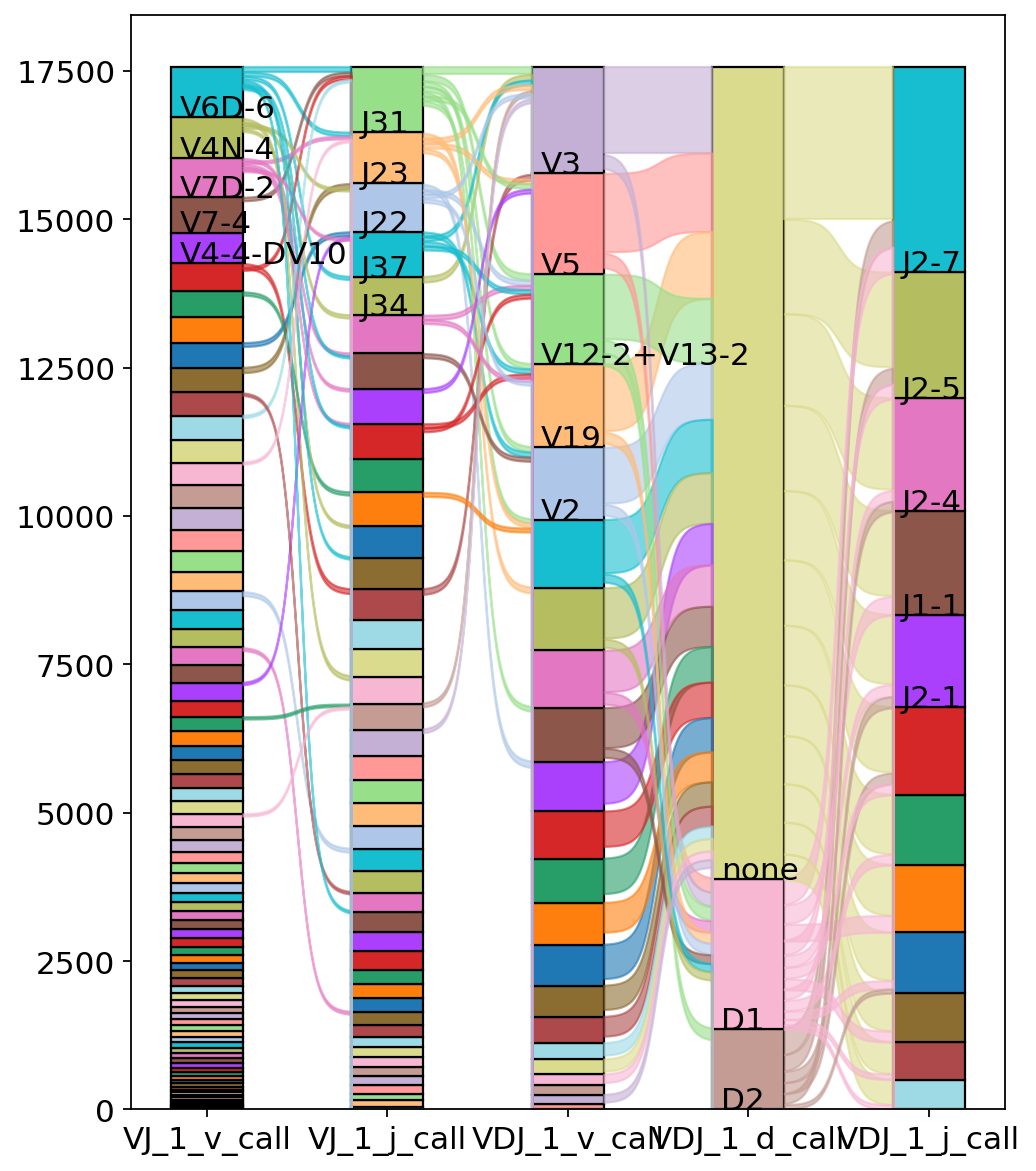

In [69]:
# ── V(D)J combination Sankey diagram ─────────────────────────────────────────
# Shows the most common TRAV–TRAJ–TRBV–TRBJ combinations
with ir.get.airr_context(mdata, ["v_call", "d_call", "j_call"]):
    _ = ir.pl.vdj_usage(
        mdata,
        full_combination=False,
        max_segments=None,
        max_ribbons=30,
        fig_kws={"figsize": [7, 9]}
    )

## CDR3 Spectratype

CDR3 length distribution of the β-chain (TRB/VDJ).  
- A **flat distribution** indicates a polyclonal repertoire  
- **Sharp peaks** at specific lengths indicate dominant clones

In [70]:
# ── Join GEX metadata into airr obs for spectratype ──────────────────────────
# ir.pl.spectratype uses adata.obs directly, not obsm; work on mdata["airr"]
# and pull tissue/treg_status from the authoritative GEX obs via reindex
mdata["airr"].obs["tissue"] = mdata.obs["gex:tissue"].reindex(mdata["airr"].obs_names)
mdata["airr"].obs["treg_status"] = mdata.obs["gex:treg_status"].reindex(mdata["airr"].obs_names)

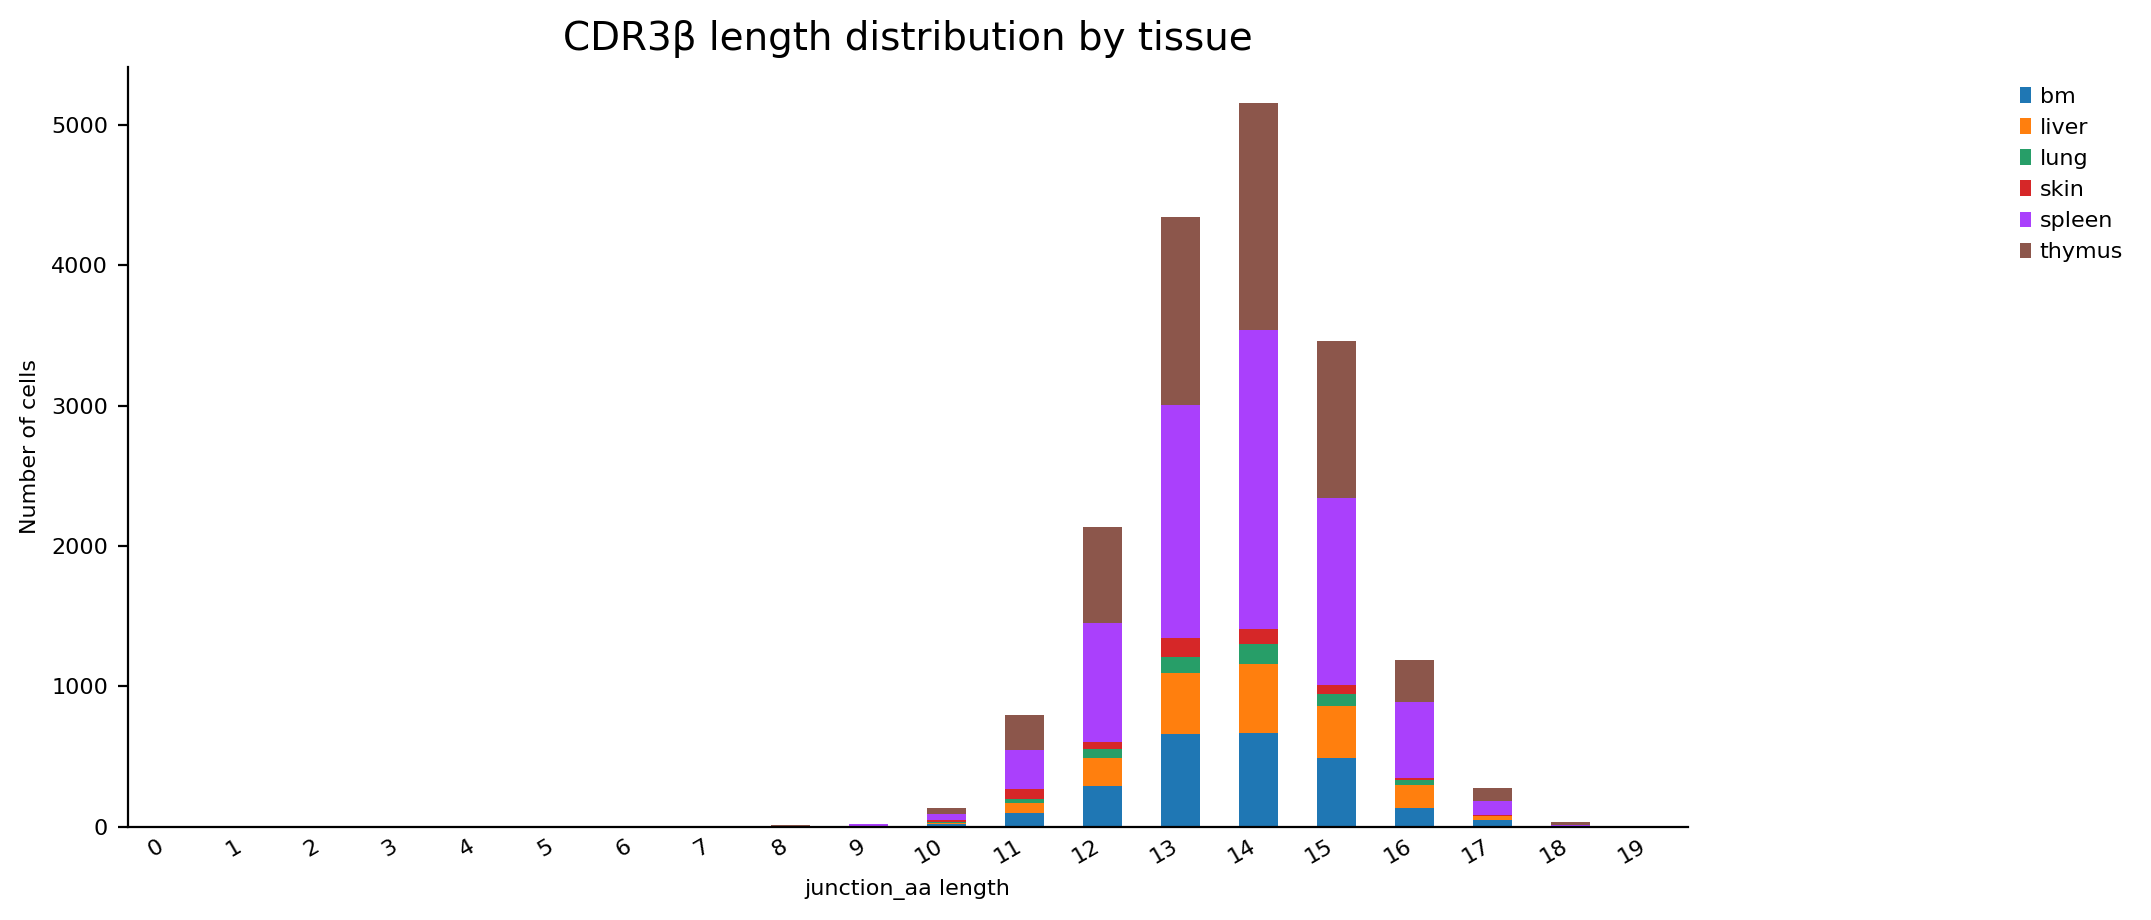

In [71]:
# ── CDR3 β-chain length by tissue (bar) ──────────────────────────────────────
_ = ir.pl.spectratype(
    mdata["airr"],
    chain="VDJ_1",
    color="tissue",
    viztype="bar",
    fig_kws={"dpi": 100},
    figsize=[10, 5]
)
plt.title("CDR3\u03b2 length distribution by tissue")
plt.show()

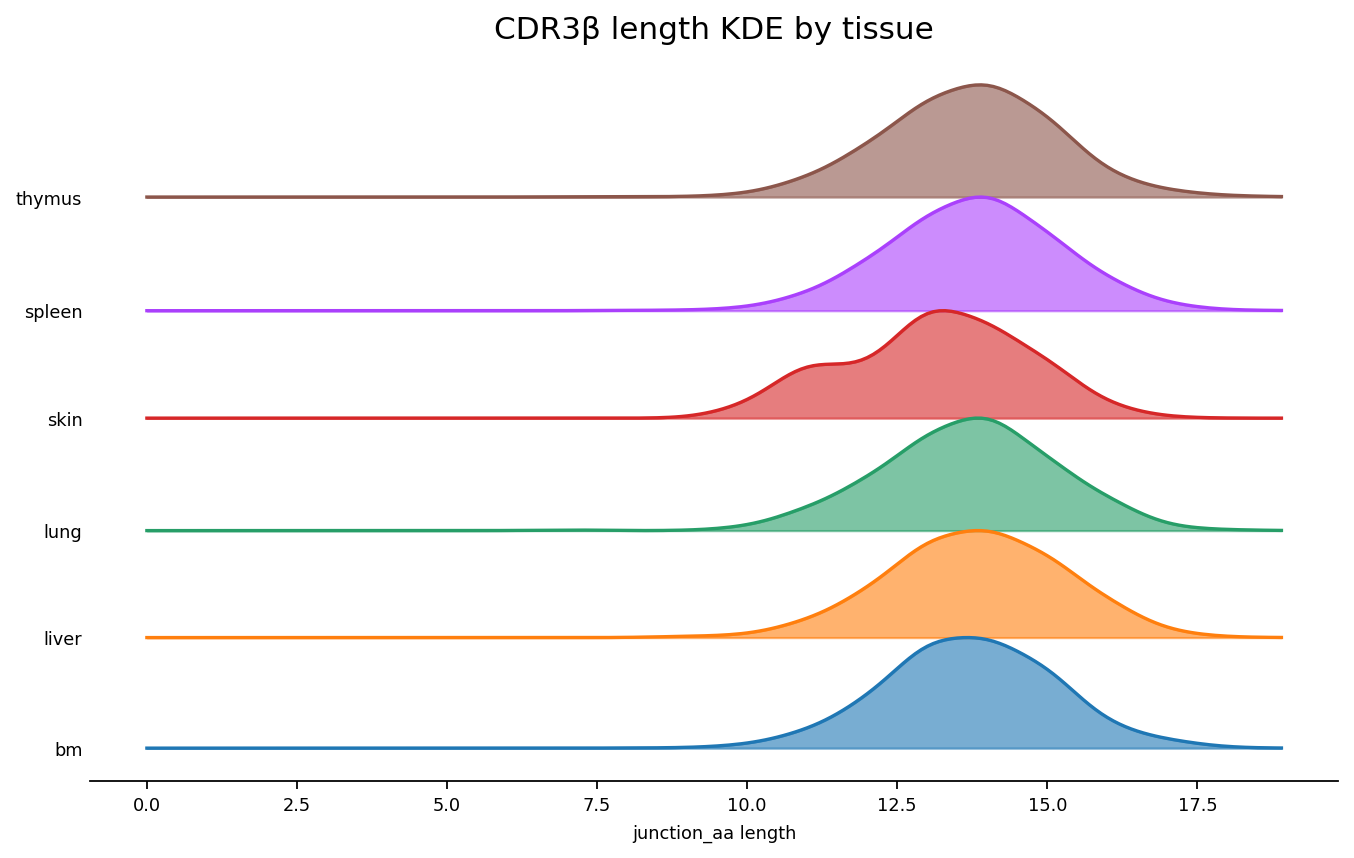

In [72]:
# ── CDR3 β-chain length by tissue (KDE curves) ───────────────────────────────
_ = ir.pl.spectratype(
    mdata["airr"],
    chain="VDJ_1",
    color="tissue",
    viztype="curve",
    curve_layout="shifted",
    fig_kws={"figsize": [10, 6]},
    kde_kws={"kde_norm": False}
)
plt.title("CDR3\u03b2 length KDE by tissue")
plt.show()

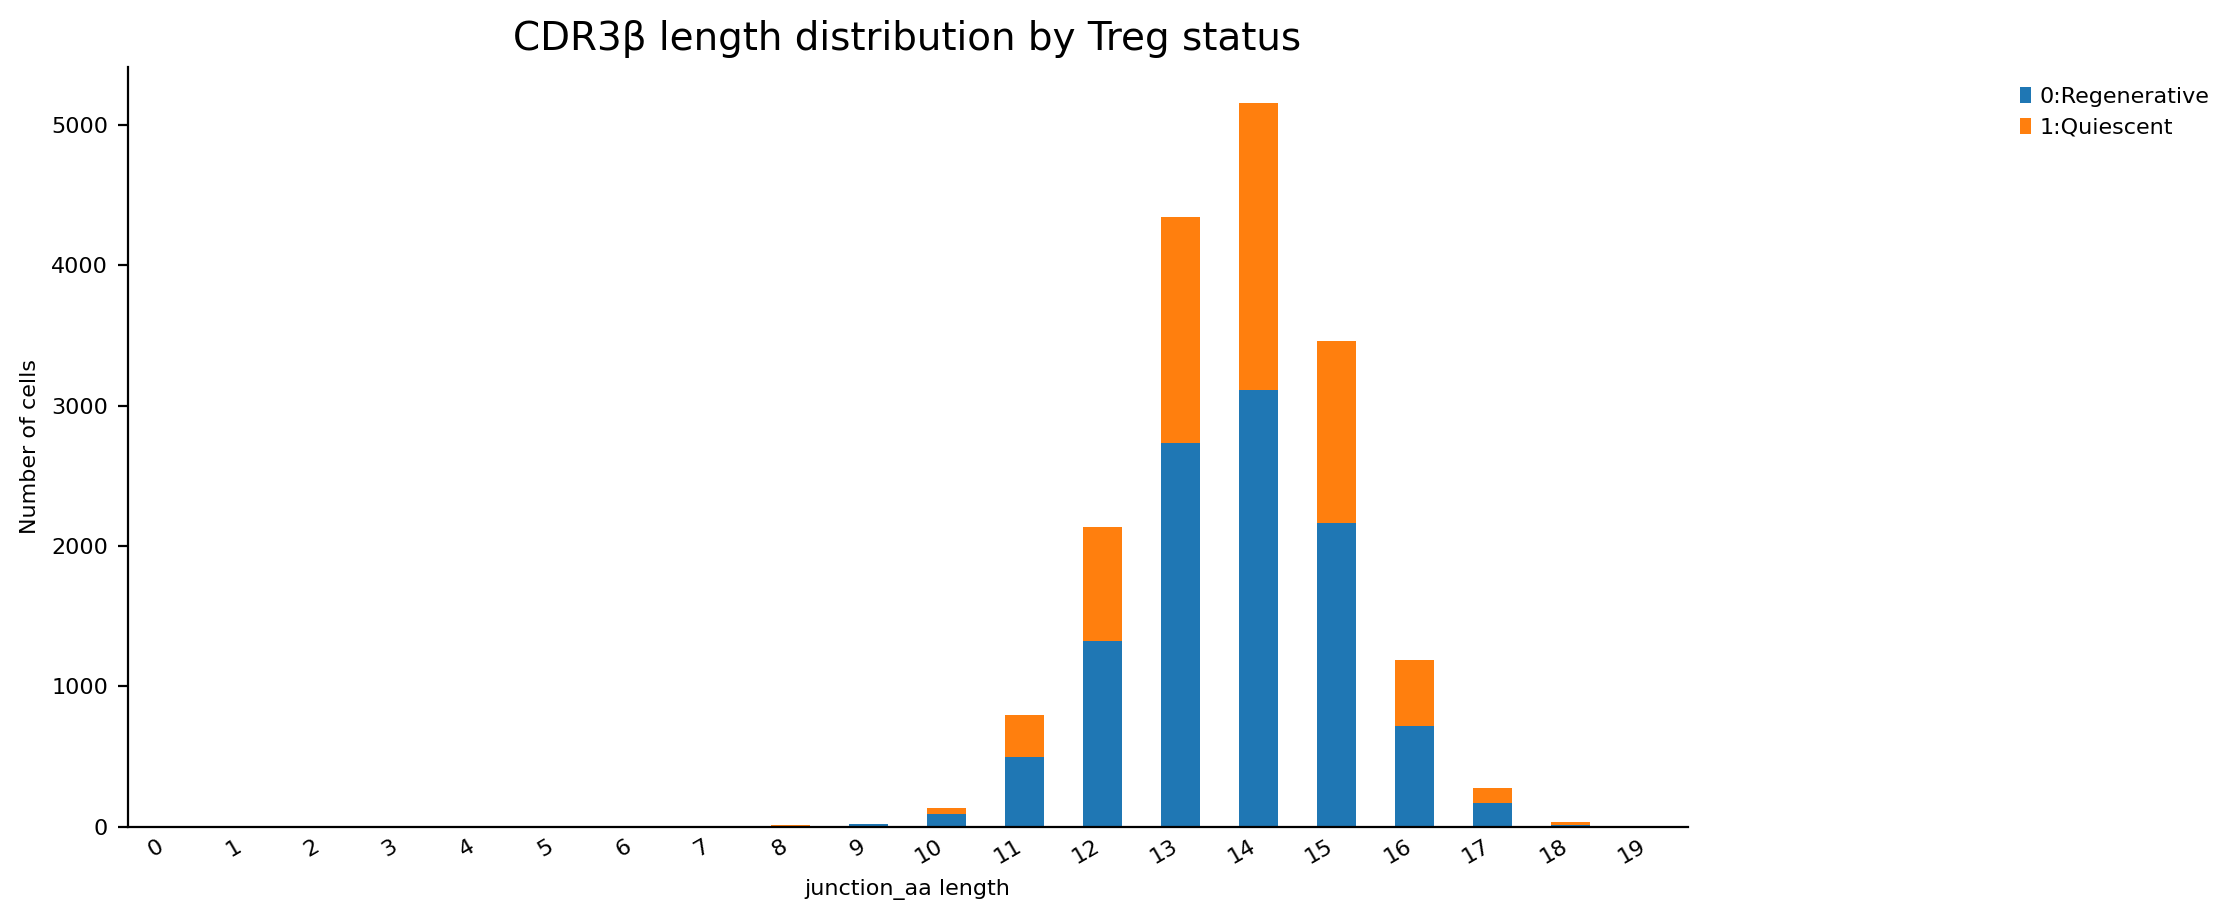

In [73]:
# ── CDR3 β-chain length by Treg status (bar) ─────────────────────────────────
_ = ir.pl.spectratype(
    mdata["airr"],
    chain="VDJ_1",
    color="treg_status",
    viztype="bar",
    fig_kws={"dpi": 100},
    figsize=[10, 5]
)
plt.title("CDR3\u03b2 length distribution by Treg status")
plt.show()

## Clonotype Abundance

Which clonotype clusters dominate each tissue and Treg subtype, and which tissues share the most clones?

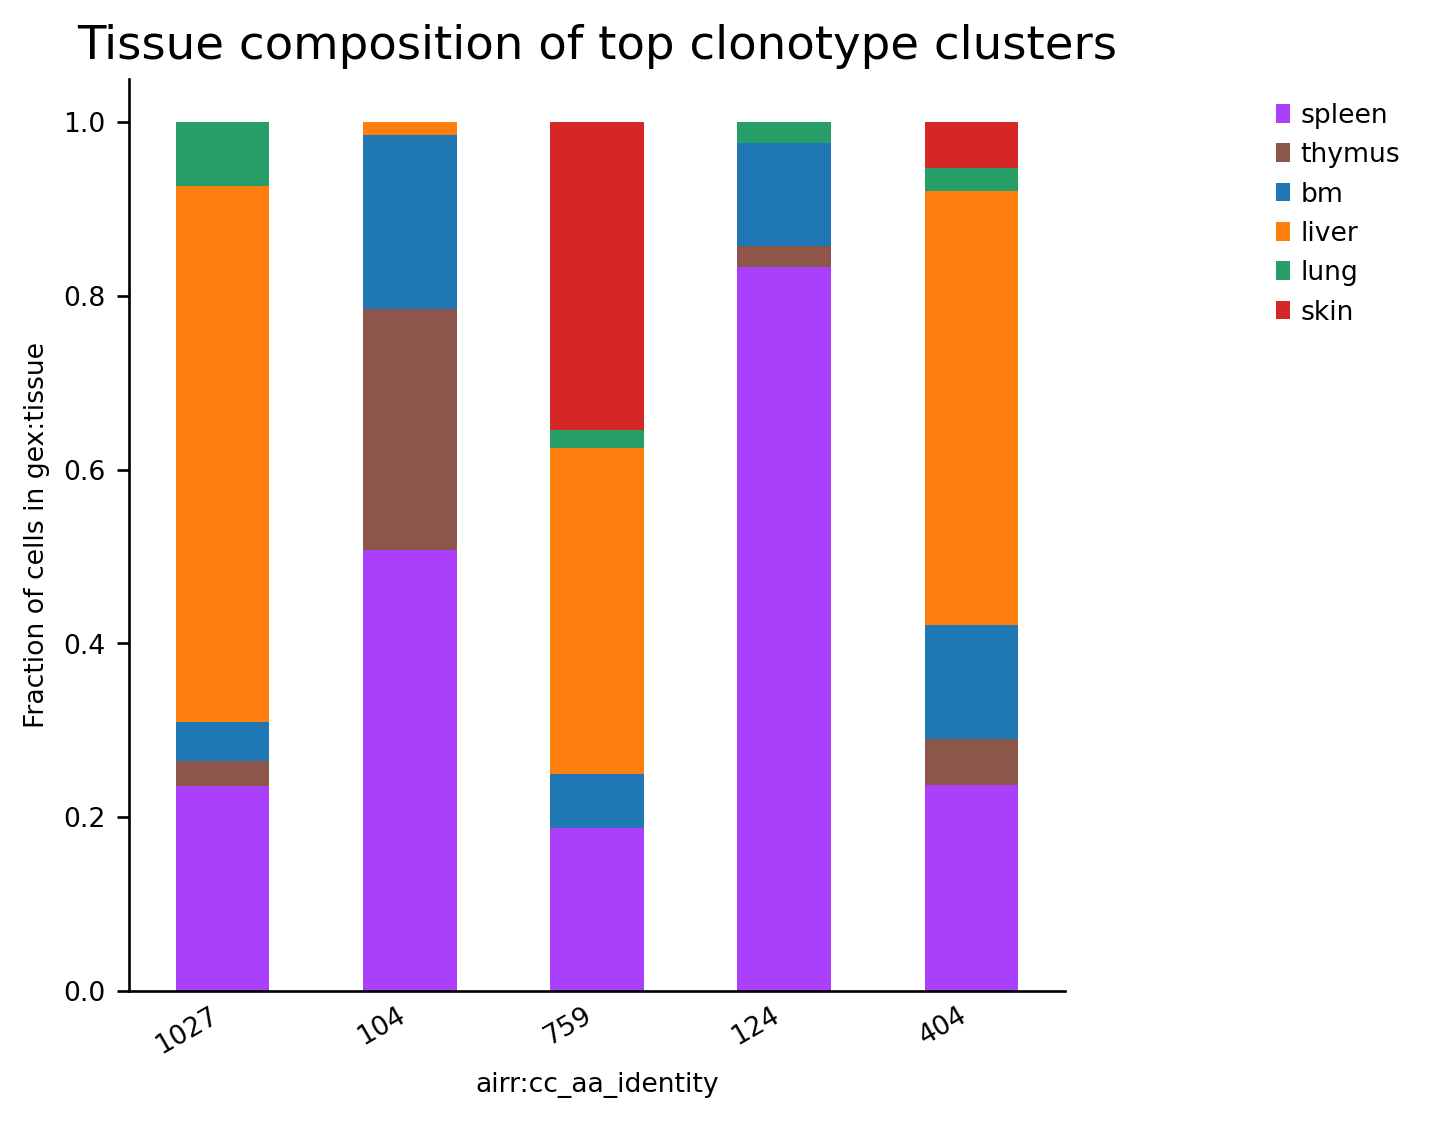

In [74]:
# ── Tissue composition of the top expanded clonotype clusters ─────────────────
_ = ir.pl.group_abundance(
    mdata,
    groupby="airr:cc_aa_identity",
    target_col="gex:tissue",
    max_cols=5,
    normalize=True,
    figsize=[5, 5]
)
plt.title("Tissue composition of top clonotype clusters")
plt.show()

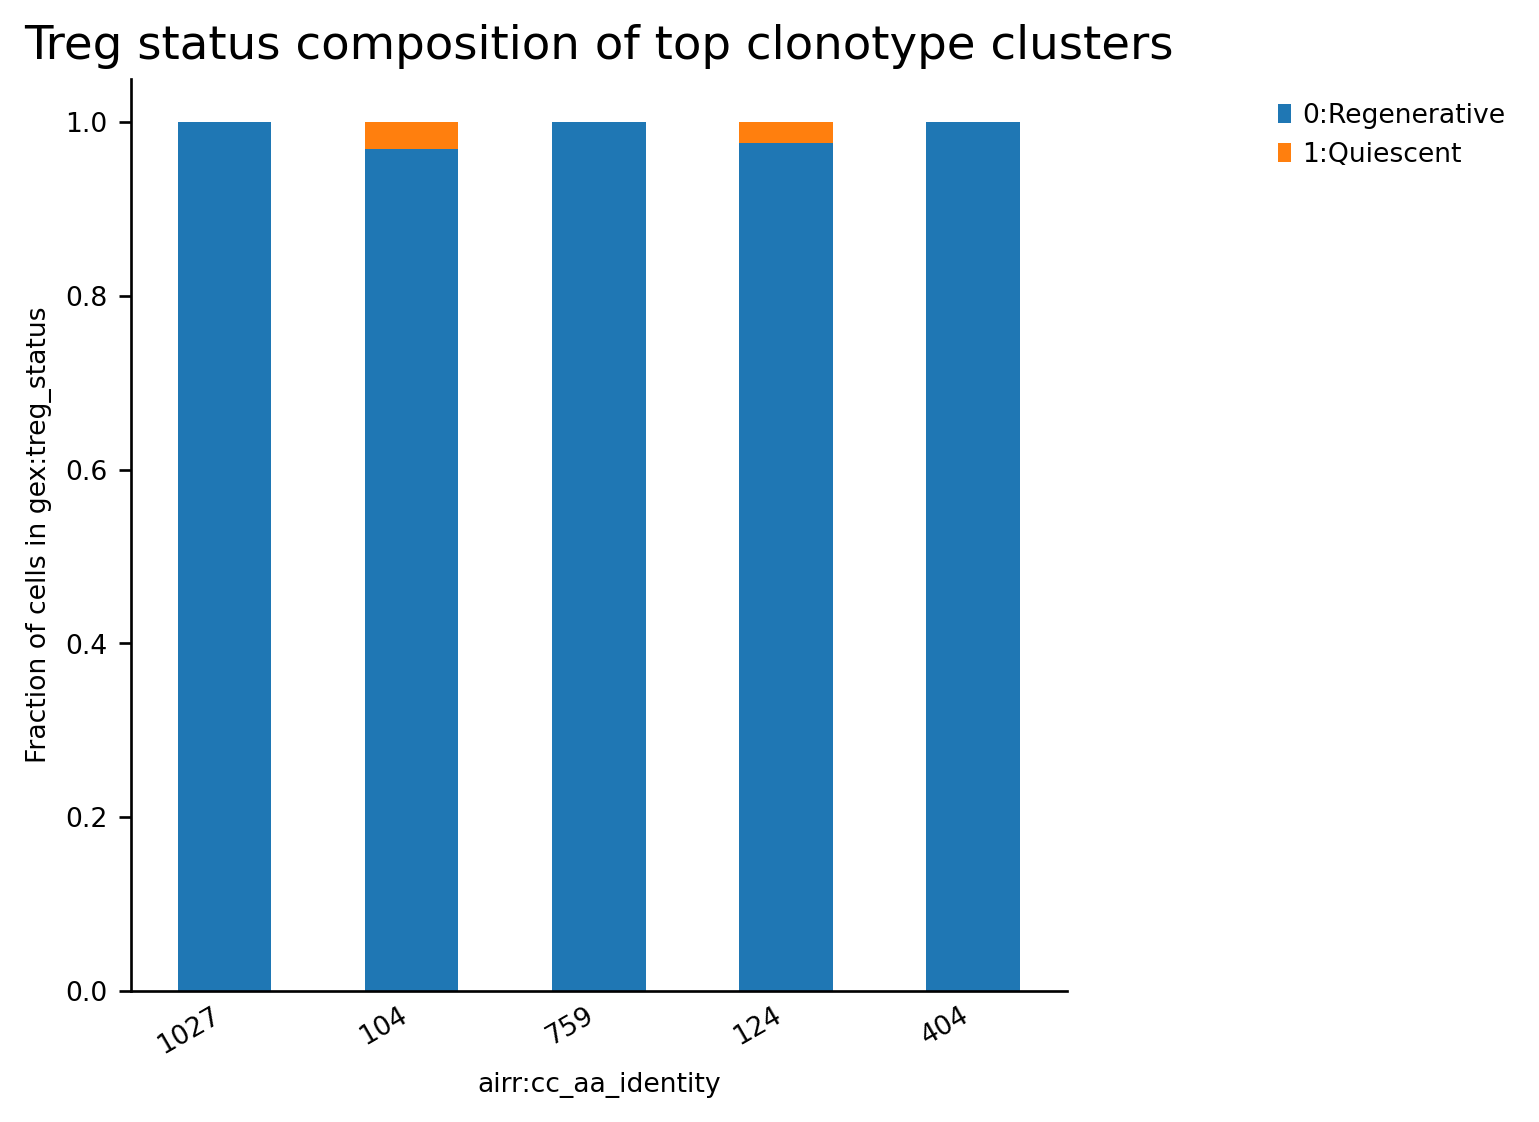

In [75]:
# ── Treg status composition of the top expanded clonotype clusters ────────────
_ = ir.pl.group_abundance(
    mdata,
    groupby="airr:cc_aa_identity",
    target_col="gex:treg_status",
    max_cols=5,
    normalize=True,
    figsize=[5, 5]
)
plt.title("Treg status composition of top clonotype clusters")
plt.show()

## Save Outputs

In [76]:
# ── Save processed MuData object ─────────────────────────────────────────────
out_h5mu = file_outputs + "mdata_tcr_processed.h5mu"
mdata.write(out_h5mu)
print(f"Saved MuData: {out_h5mu}")

# ── Save cell-level metadata as CSV ──────────────────────────────────────────
out_obs = file_outputs + "mdata_tcr_obs.csv"
mdata.obs.to_csv(out_obs)
print(f"Saved obs CSV: {out_obs}")

Saved MuData: 1_outputs/mdata_tcr_processed.h5mu
Saved obs CSV: 1_outputs/mdata_tcr_obs.csv
